# XGBoost Feature Selection

In [7]:
# Data Import
import sys
sys.path.append('../Data_Processing')
from full_cleaning_preprocessing_script import run_full_preprocessing

# General
import pandas as pd
import numpy as np
import os
from typing import List
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
from scipy.stats import skew

Taking data from the longest period where we have complete data. Looking at the final file 2024 ends with the highest level of data, limited by the lake data.

In [3]:
df = run_full_preprocessing(
    data_folder = "/home/jpelletier/Downloads/data",
    start_date = "2014-01-01",
    end_date = "2024-12-31"
)

DUCKSTRADAMUS — FULL PREPROCESSING PIPELINE
  data_folder : /home/jpelletier/Downloads/data
  date range  : 2014-01-01  →  2024-12-31
  save_path   : None

[1/9] Wholesale price...
      Anchor df shape: (96408, 10)

[2/9] Generation output...
      Shape after merge: (96408, 19)

[3/9] Wind...
      Shape after merge: (96408, 29)

[4/9] Solar...
      Shape after merge: (96408, 41)

[5/9] Temperature...
      Shape after merge: (96408, 47)

[6/9] Lake storage...
      Merged: NI_TPO_Storage_LakeTaupo.csv  (prefix: 'NI_TPO_')
      Merged: NI_WKA_Storage_LakeWaikaremoana.csv  (prefix: 'NI_WKA_')
      Merged: SI_HWE_Storage_LakeHawea.csv  (prefix: 'SI_HWE_')
      Merged: SI_MAN_Storage_LakeManapouri.csv  (prefix: 'SI_MAN_')
      Merged: SI_OHA_Storage_LakeOhau.csv  (prefix: 'SI_OHA_')
      Merged: SI_PKI_Storage_LakePukaki.csv  (prefix: 'SI_PKI_')
      Merged: SI_TAU_Storage_LakeTeAnau.csv  (prefix: 'SI_TAU_')
      Merged: SI_TKA_Storage_LakeTekapo.csv  (prefix: 'SI_TKA_')
      M

In [4]:
target = 'el_price_dol_MWh_OTA2201'
print(f"df shape: {df.shape}")
print(f"target:   {target}")
df.head()

df shape: (96408, 81)
target:   el_price_dol_MWh_OTA2201


,datetime_utc12,el_price_dol_MWh_BEN2201,el_price_dol_MWh_HAY2201,el_price_dol_MWh_INV2201,el_price_dol_MWh_ISL2201,el_price_dol_MWh_KIK2201,el_price_dol_MWh_OTA2201,el_price_dol_MWh_RDF2201,el_price_dol_MWh_SFD2201,el_price_dol_MWh_WKM2201,...,demand_GWh_UNI,demand_GWh_USI,avg_flow_MW,peak_flow_MW,Direction,outage_Gas_MW,outage_Hyd_MW,outage_Ter_MW,outage_Win_MW,outage_UNKN_MW
0,2014-01-01 00:00:00,33.755,34.900,34.265,34.720,NaN,37.845,36.420,36.195,36.865,...,0.868,0.426,373.0,386.0,1.0,0.0,50.2,250.0,0.0,0.0
1,2014-01-01 01:00:00,32.455,33.555,32.945,33.385,NaN,36.350,35.000,34.785,35.425,...,0.818,0.375,366.0,367.0,1.0,0.0,50.2,250.0,0.0,0.0
2,2014-01-01 02:00:00,5.555,5.745,5.635,5.710,NaN,6.215,5.975,5.950,6.050,...,0.778,0.347,326.0,328.0,1.0,0.0,50.2,250.0,0.0,0.0
3,2014-01-01 03:00:00,3.865,3.990,3.920,3.970,NaN,4.315,4.150,4.135,4.210,...,0.762,0.338,293.5,319.0,1.0,0.0,50.2,250.0,0.0,0.0
4,2014-01-01 04:00:00,2.525,2.605,2.565,2.595,NaN,2.815,2.695,2.700,2.745,...,0.764,0.351,288.0,314.0,1.0,0.0,50.2,250.0,0.0,0.0


### Cell 2 — Add aggregate features

In [5]:
demand_cols = [col for col in df.columns if 'demand' in col.lower()]
df['total_demand'] = df[demand_cols].sum(axis=1)

lake_cols = [col for col in df.columns if 'storage' in col.lower()]
df['total_lakes'] = df[lake_cols].sum(axis=1)

df['total_wind'] = df[[
    'palmerston_north_wind_kmh',
    'wellington_wind_kmh',
    'harapaki_hawkesbay_wind_kmh',
    'te_uku_waikato_wind_kmh',
    'kaiwera_downs_southland_wind_kmh',
]].sum(axis=1)

solar_cols = [col for col in df.columns if 'sunshine' in col.lower() or 'shortwave' in col.lower()]
df['total_solar'] = df[solar_cols].sum(axis=1)

print(f"df shape after aggregates: {df.shape}")
df[['total_demand', 'total_lakes', 'total_wind', 'total_solar']].describe()

df shape after aggregates: (96408, 85)


,total_demand,total_lakes,total_wind,total_solar
count,96408.000000,96408.000000,96408.000000,96408.000000
mean,4.699324,4741.216675,123.165164,9329.537233
std,0.802557,1041.585541,44.592169,10359.861667
min,0.000000,0.000000,0.000000,0.000000
25%,4.023000,4016.456656,89.900000,0.000000
50%,4.788000,4711.294146,117.900000,1156.295000
75%,5.266000,5493.241563,151.300000,20393.000000
max,7.246000,8656.800000,320.200000,27934.000000


### Cell 3 — Distribution review

In [8]:
def review_distributions(df, skew_threshold=0.9):
    """
    Score each numeric feature's skewness and flag which need log1p.

    Rule of thumb:
      |skew| < 0.5    → roughly symmetric (no transform)
      0.5 ≤ |skew| < 1 → moderately skewed (optional)
      |skew| ≥ threshold → log1p recommended (if data is non-negative)
    """
    rows = []
    for col in df.select_dtypes(include='number').columns:
        s = df[col].dropna()
        if len(s) == 0:
            continue

        sk      = skew(s)
        min_val = s.min()
        can_log = min_val >= 0    # log1p needs non-negative data

        needs_log = (abs(sk) >= skew_threshold) and can_log

        rows.append({
            'feature':             col,
            'skew':                round(sk, 2),
            'min':                 round(min_val, 2),
            'max':                 round(s.max(), 2),
            'can_log':             can_log,
            'needs_log_transform': needs_log,
            'category':            ('highly skewed'     if abs(sk) >= 1.0
                                    else 'moderately skewed' if abs(sk) >= 0.5
                                    else 'roughly symmetric'),
        })

    return (
        pd.DataFrame(rows)
        .sort_values('skew', key=abs, ascending=False)
        .reset_index(drop=True)
    )

dist_summary = review_distributions(df, skew_threshold=0.9)

n_flagged    = dist_summary['needs_log_transform'].sum()
n_skewed_neg = (~dist_summary['can_log'] & (dist_summary['skew'].abs() >= 0.9)).sum()

print(f"Features flagged for log1p:                 {n_flagged}")
print(f"Skewed features that can't be logged (neg): {n_skewed_neg}")
print()
dist_summary

Features flagged for log1p:                 28
Skewed features that can't be logged (neg): 2



,feature,skew,min,max,can_log,needs_log_transform,category
0,Ele,310.44,0.00,4886.00,True,True,highly skewed
1,Diesel,13.28,0.00,159612.00,True,True,highly skewed
2,el_price_dol_MWh_RDF2201,9.18,0.00,5452.30,True,True,highly skewed
3,el_price_dol_MWh_OTA2201,8.77,0.00,6046.32,True,True,highly skewed
4,el_price_dol_MWh_WKM2201,8.35,0.00,5542.44,True,True,highly skewed
...,...,...,...,...,...,...,...
79,Hydro,-0.05,562382.00,4706415.00,True,False,roughly symmetric
80,SI_HWE__lake_level_m,0.04,338.33,346.03,True,False,roughly symmetric
81,demand_GWh_USI,-0.03,0.00,1.13,True,False,roughly symmetric
82,demand_GWh_UNI,0.02,0.00,2.40,True,False,roughly symmetric


### Cell 4 — Visualize the BEFORE distributions of flagged features

Plotting 28 features flagged for log1p (BEFORE transform):


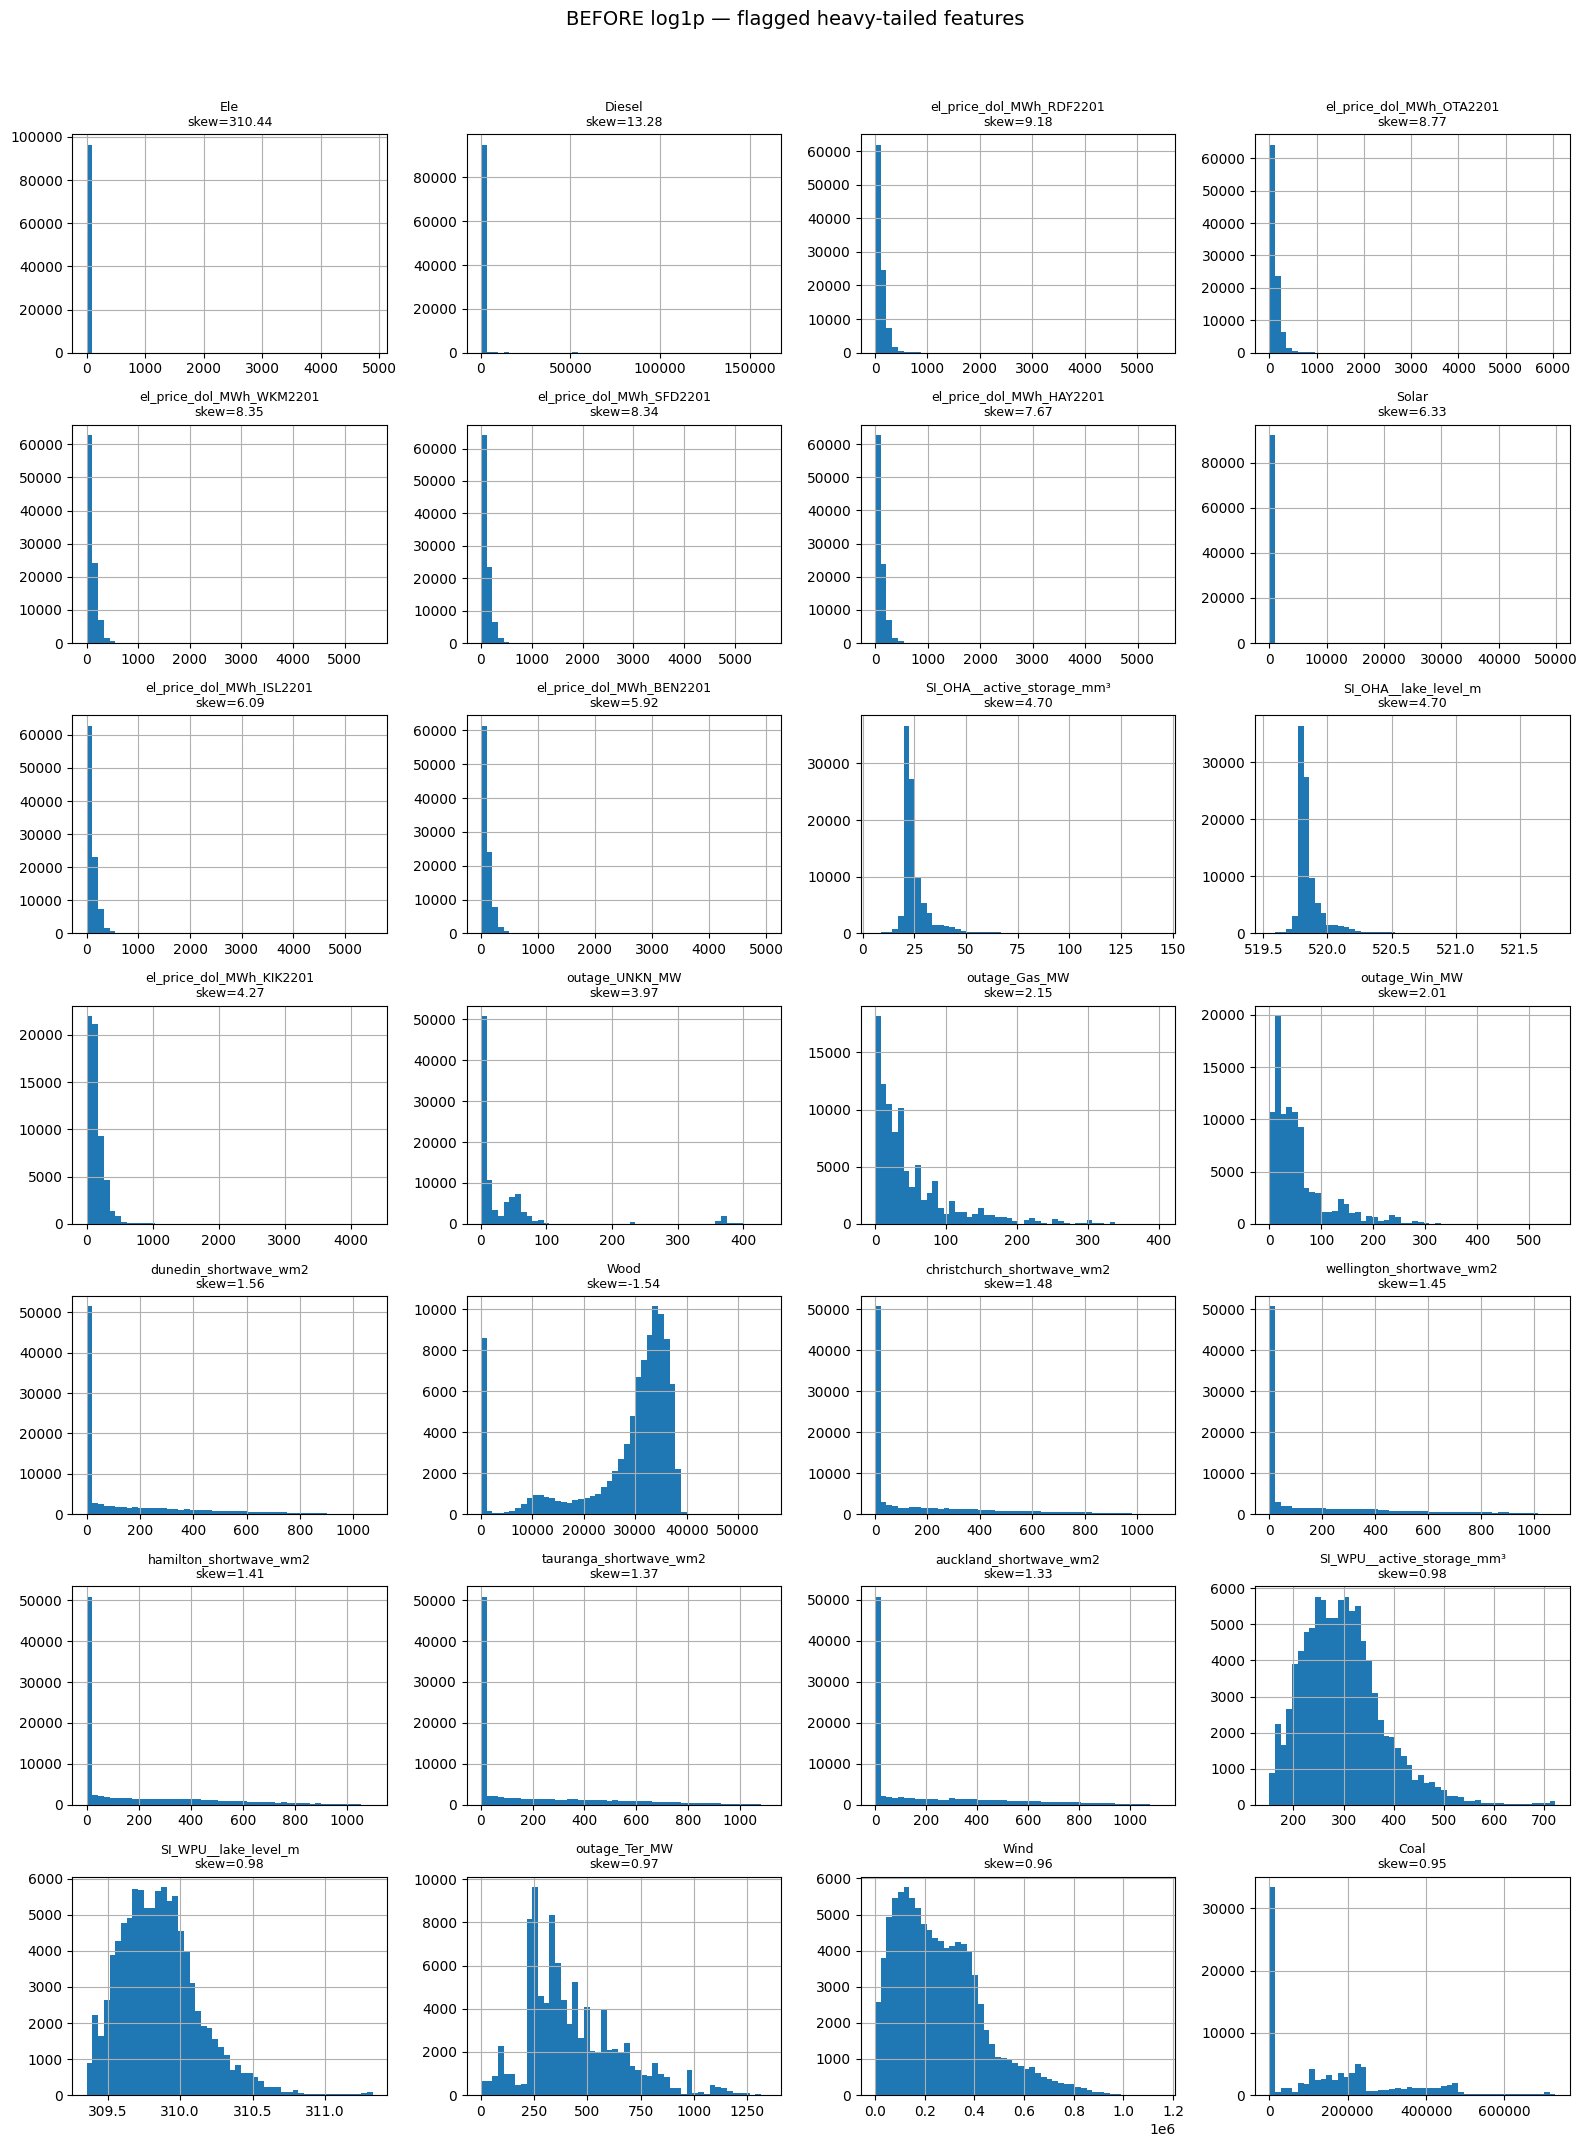

In [9]:
def plot_distributions(df, features, ncols=4, suptitle=None):
    if len(features) == 0:
        print("No features to plot.")
        return

    nrows = (len(features) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3))
    axes = np.array(axes).flatten() if nrows * ncols > 1 else [axes]

    for i, col in enumerate(features):
        s = df[col].dropna()
        s.hist(bins=50, ax=axes[i])
        axes[i].set_title(f'{col}\nskew={s.skew():.2f}', fontsize=9)

    for j in range(len(features), len(axes)):
        axes[j].axis('off')

    if suptitle:
        plt.suptitle(suptitle, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

flagged_features = dist_summary.loc[dist_summary['needs_log_transform'], 'feature'].tolist()

print(f"Plotting {len(flagged_features)} features flagged for log1p (BEFORE transform):")
plot_distributions(df, flagged_features, suptitle='BEFORE log1p — flagged heavy-tailed features')

### Cell 5 — Apply log1p transform

In [10]:
already_transformed = set()

def apply_log_transforms(df, dist_summary, target, already_transformed=None):
    """
    Applies log1p to flagged features in-place. Tracks which columns have been
    transformed to prevent accidental double-transforms on re-run.
    """
    if already_transformed is None:
        already_transformed = set()

    features_to_transform = dist_summary.loc[
        dist_summary['needs_log_transform'], 'feature'
    ].tolist()

    transformed_now = []
    skipped_double  = []

    for col in features_to_transform:
        if col in already_transformed:
            skipped_double.append(col)
            continue
        df[col] = np.log1p(df[col])
        already_transformed.add(col)
        transformed_now.append(col)

    target_transformed = False
    if target in features_to_transform and target not in already_transformed:
        # Already handled above (target is in features_to_transform if flagged)
        target_transformed = True
    elif target in already_transformed and target in features_to_transform:
        target_transformed = True

    return transformed_now, skipped_double, target_transformed

transformed_now, skipped_double, target_was_logged = apply_log_transforms(
    df, dist_summary, target, already_transformed
)

print(f"Transformed in this run: {len(transformed_now)} features")
print(f"Target transformed:      {target_was_logged}")
print()
if skipped_double:
    print(f"Skipped (already transformed in prior run): {len(skipped_double)} features")
    print(f"  → {skipped_double}")
print()
print("Features transformed:")
for c in transformed_now:
    print(f"  - {c}")

Transformed in this run: 28 features
Target transformed:      True


Features transformed:
  - Ele
  - Diesel
  - el_price_dol_MWh_RDF2201
  - el_price_dol_MWh_OTA2201
  - el_price_dol_MWh_WKM2201
  - el_price_dol_MWh_SFD2201
  - el_price_dol_MWh_HAY2201
  - Solar
  - el_price_dol_MWh_ISL2201
  - el_price_dol_MWh_BEN2201
  - SI_OHA__active_storage_mm³
  - SI_OHA__lake_level_m
  - el_price_dol_MWh_KIK2201
  - outage_UNKN_MW
  - outage_Gas_MW
  - outage_Win_MW
  - dunedin_shortwave_wm2
  - Wood
  - christchurch_shortwave_wm2
  - wellington_shortwave_wm2
  - hamilton_shortwave_wm2
  - tauranga_shortwave_wm2
  - auckland_shortwave_wm2
  - SI_WPU__active_storage_mm³
  - SI_WPU__lake_level_m
  - outage_Ter_MW
  - Wind
  - Coal


### Cell 6 — Verify AFTER distributions

Plotting the same 28 features AFTER log1p transform:


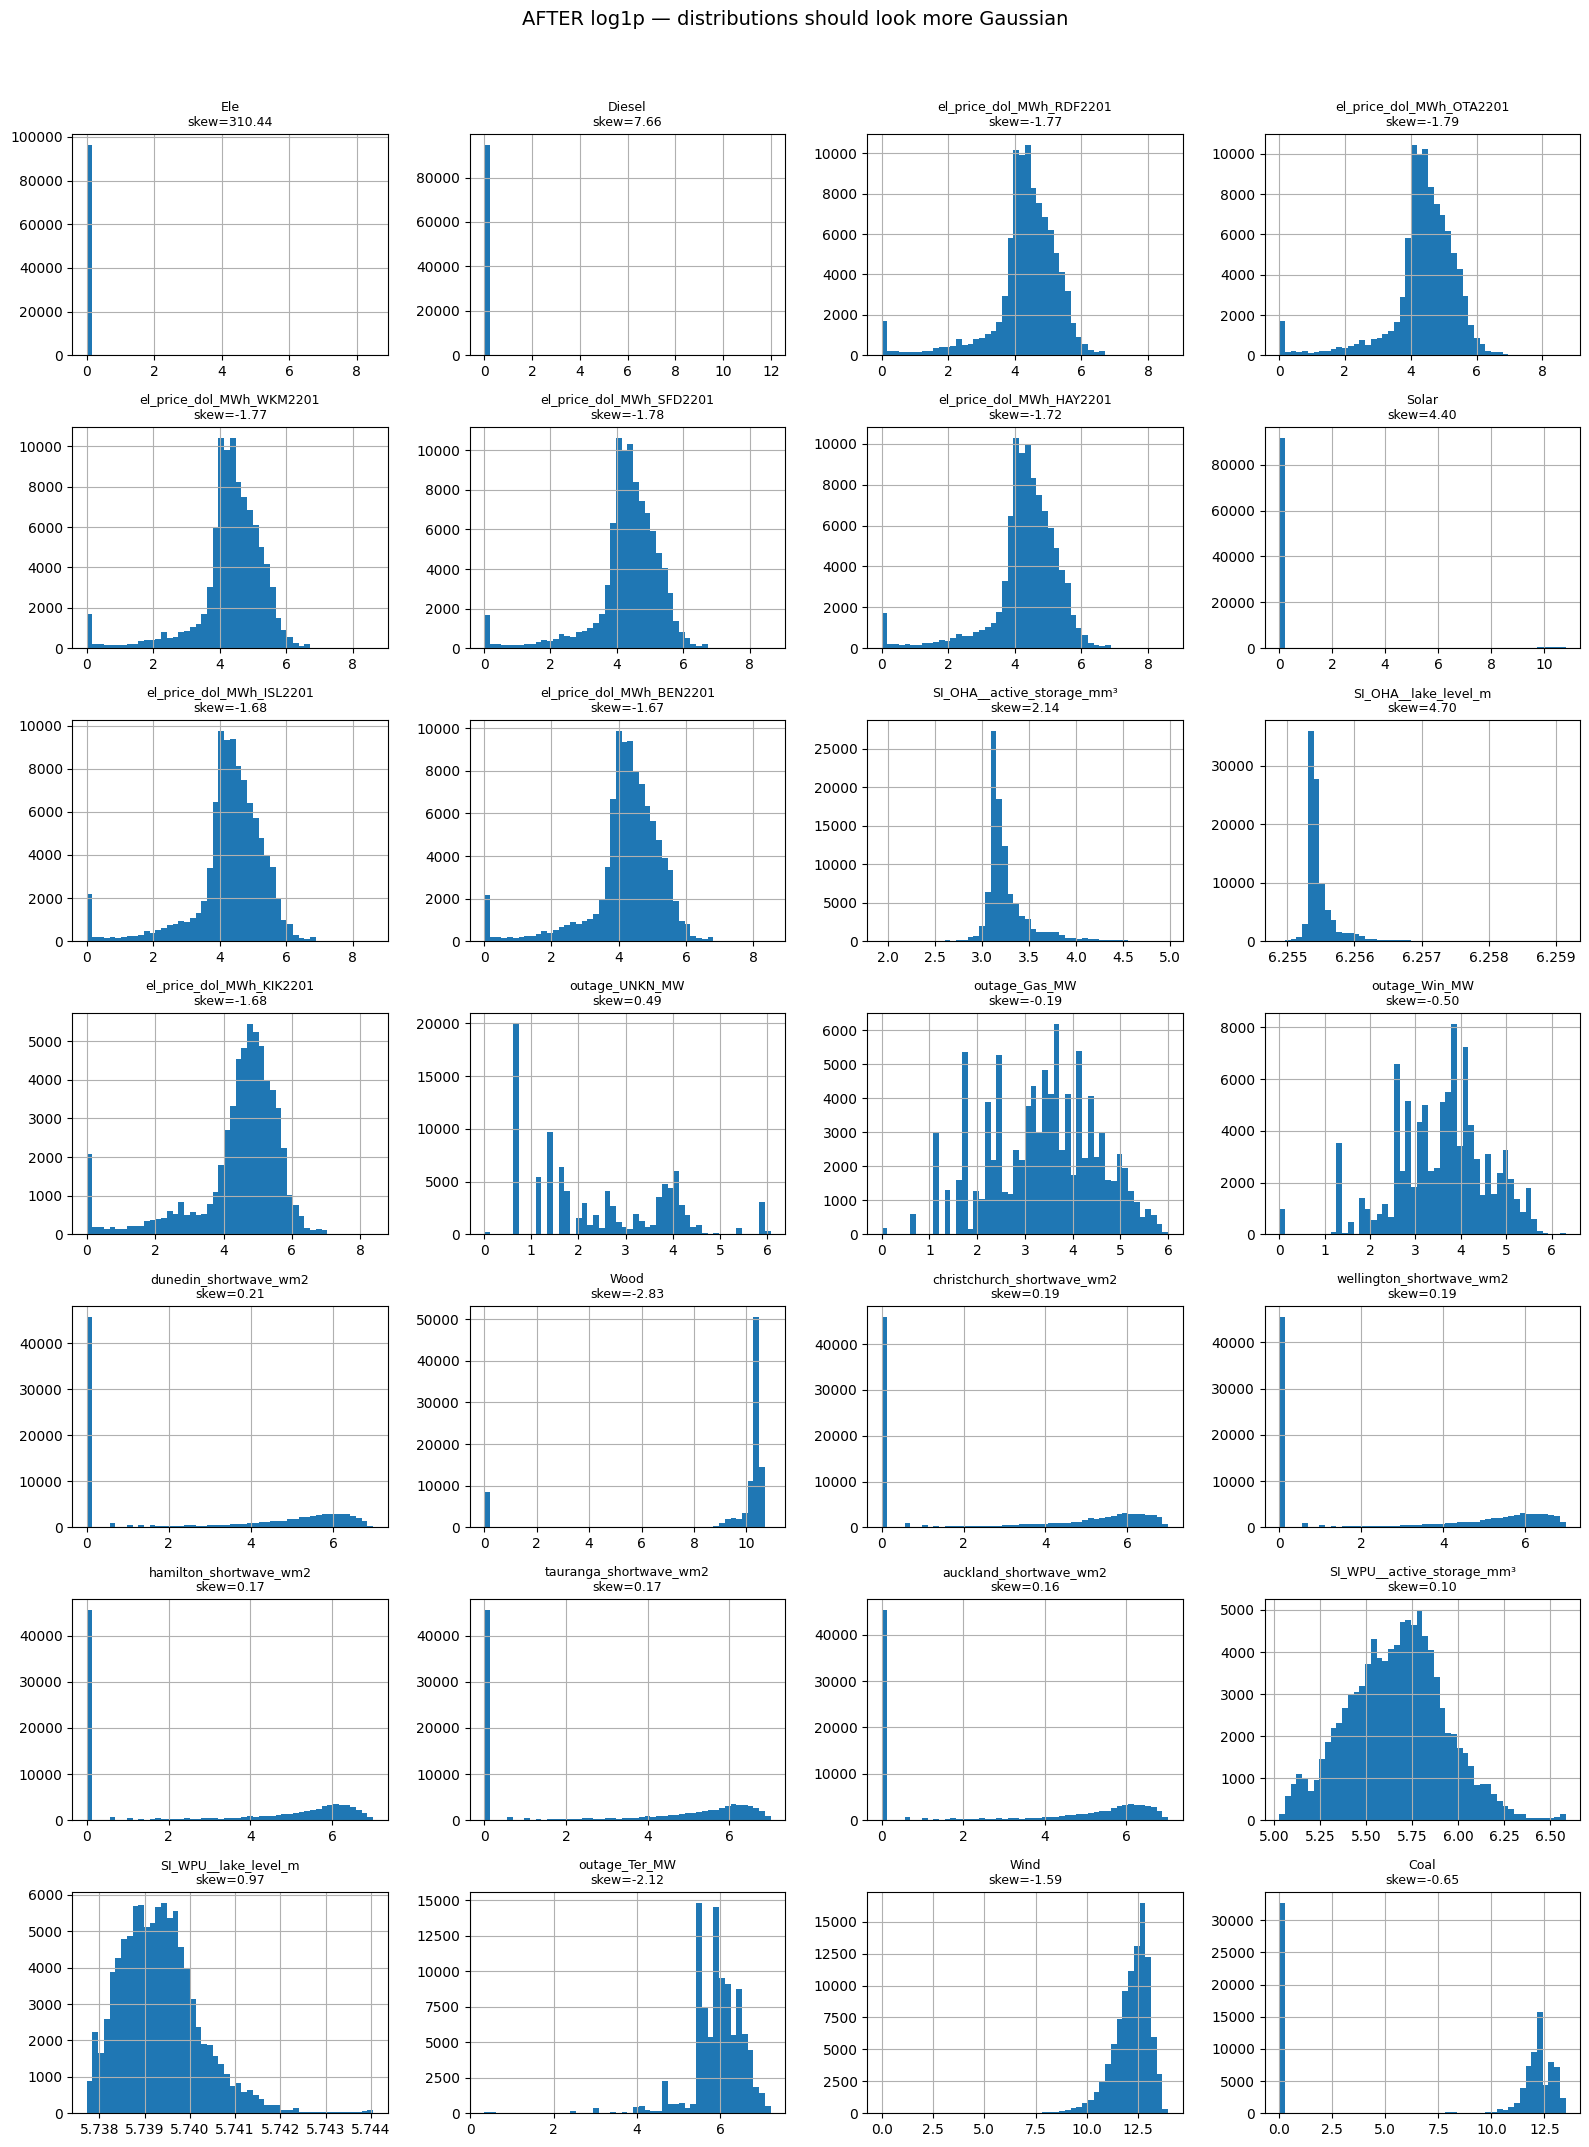

Post-transform skew check (should mostly be < 0.9 now):


,feature,skew,category
0,Ele,310.44,highly skewed
1,Diesel,7.66,highly skewed
2,SI_OHA__lake_level_m,4.70,highly skewed
3,Solar,4.40,highly skewed
4,Wood,-2.83,highly skewed
5,SI_OHA__active_storage_mm³,2.14,highly skewed
6,outage_Ter_MW,-2.12,highly skewed
7,el_price_dol_MWh_OTA2201,-1.79,highly skewed
8,el_price_dol_MWh_SFD2201,-1.78,highly skewed
9,el_price_dol_MWh_RDF2201,-1.77,highly skewed


In [11]:
print(f"Plotting the same {len(transformed_now)} features AFTER log1p transform:")
plot_distributions(df, transformed_now, suptitle='AFTER log1p — distributions should look more Gaussian')

# Re-score the transformed features to confirm skew dropped
post_summary = review_distributions(df[transformed_now], skew_threshold=0.9)
print("Post-transform skew check (should mostly be < 0.9 now):")
post_summary[['feature', 'skew', 'category']]

### Cell 7 - Run Lagged Correlations Analysis

#### 24h & 72h Lagged Correlation

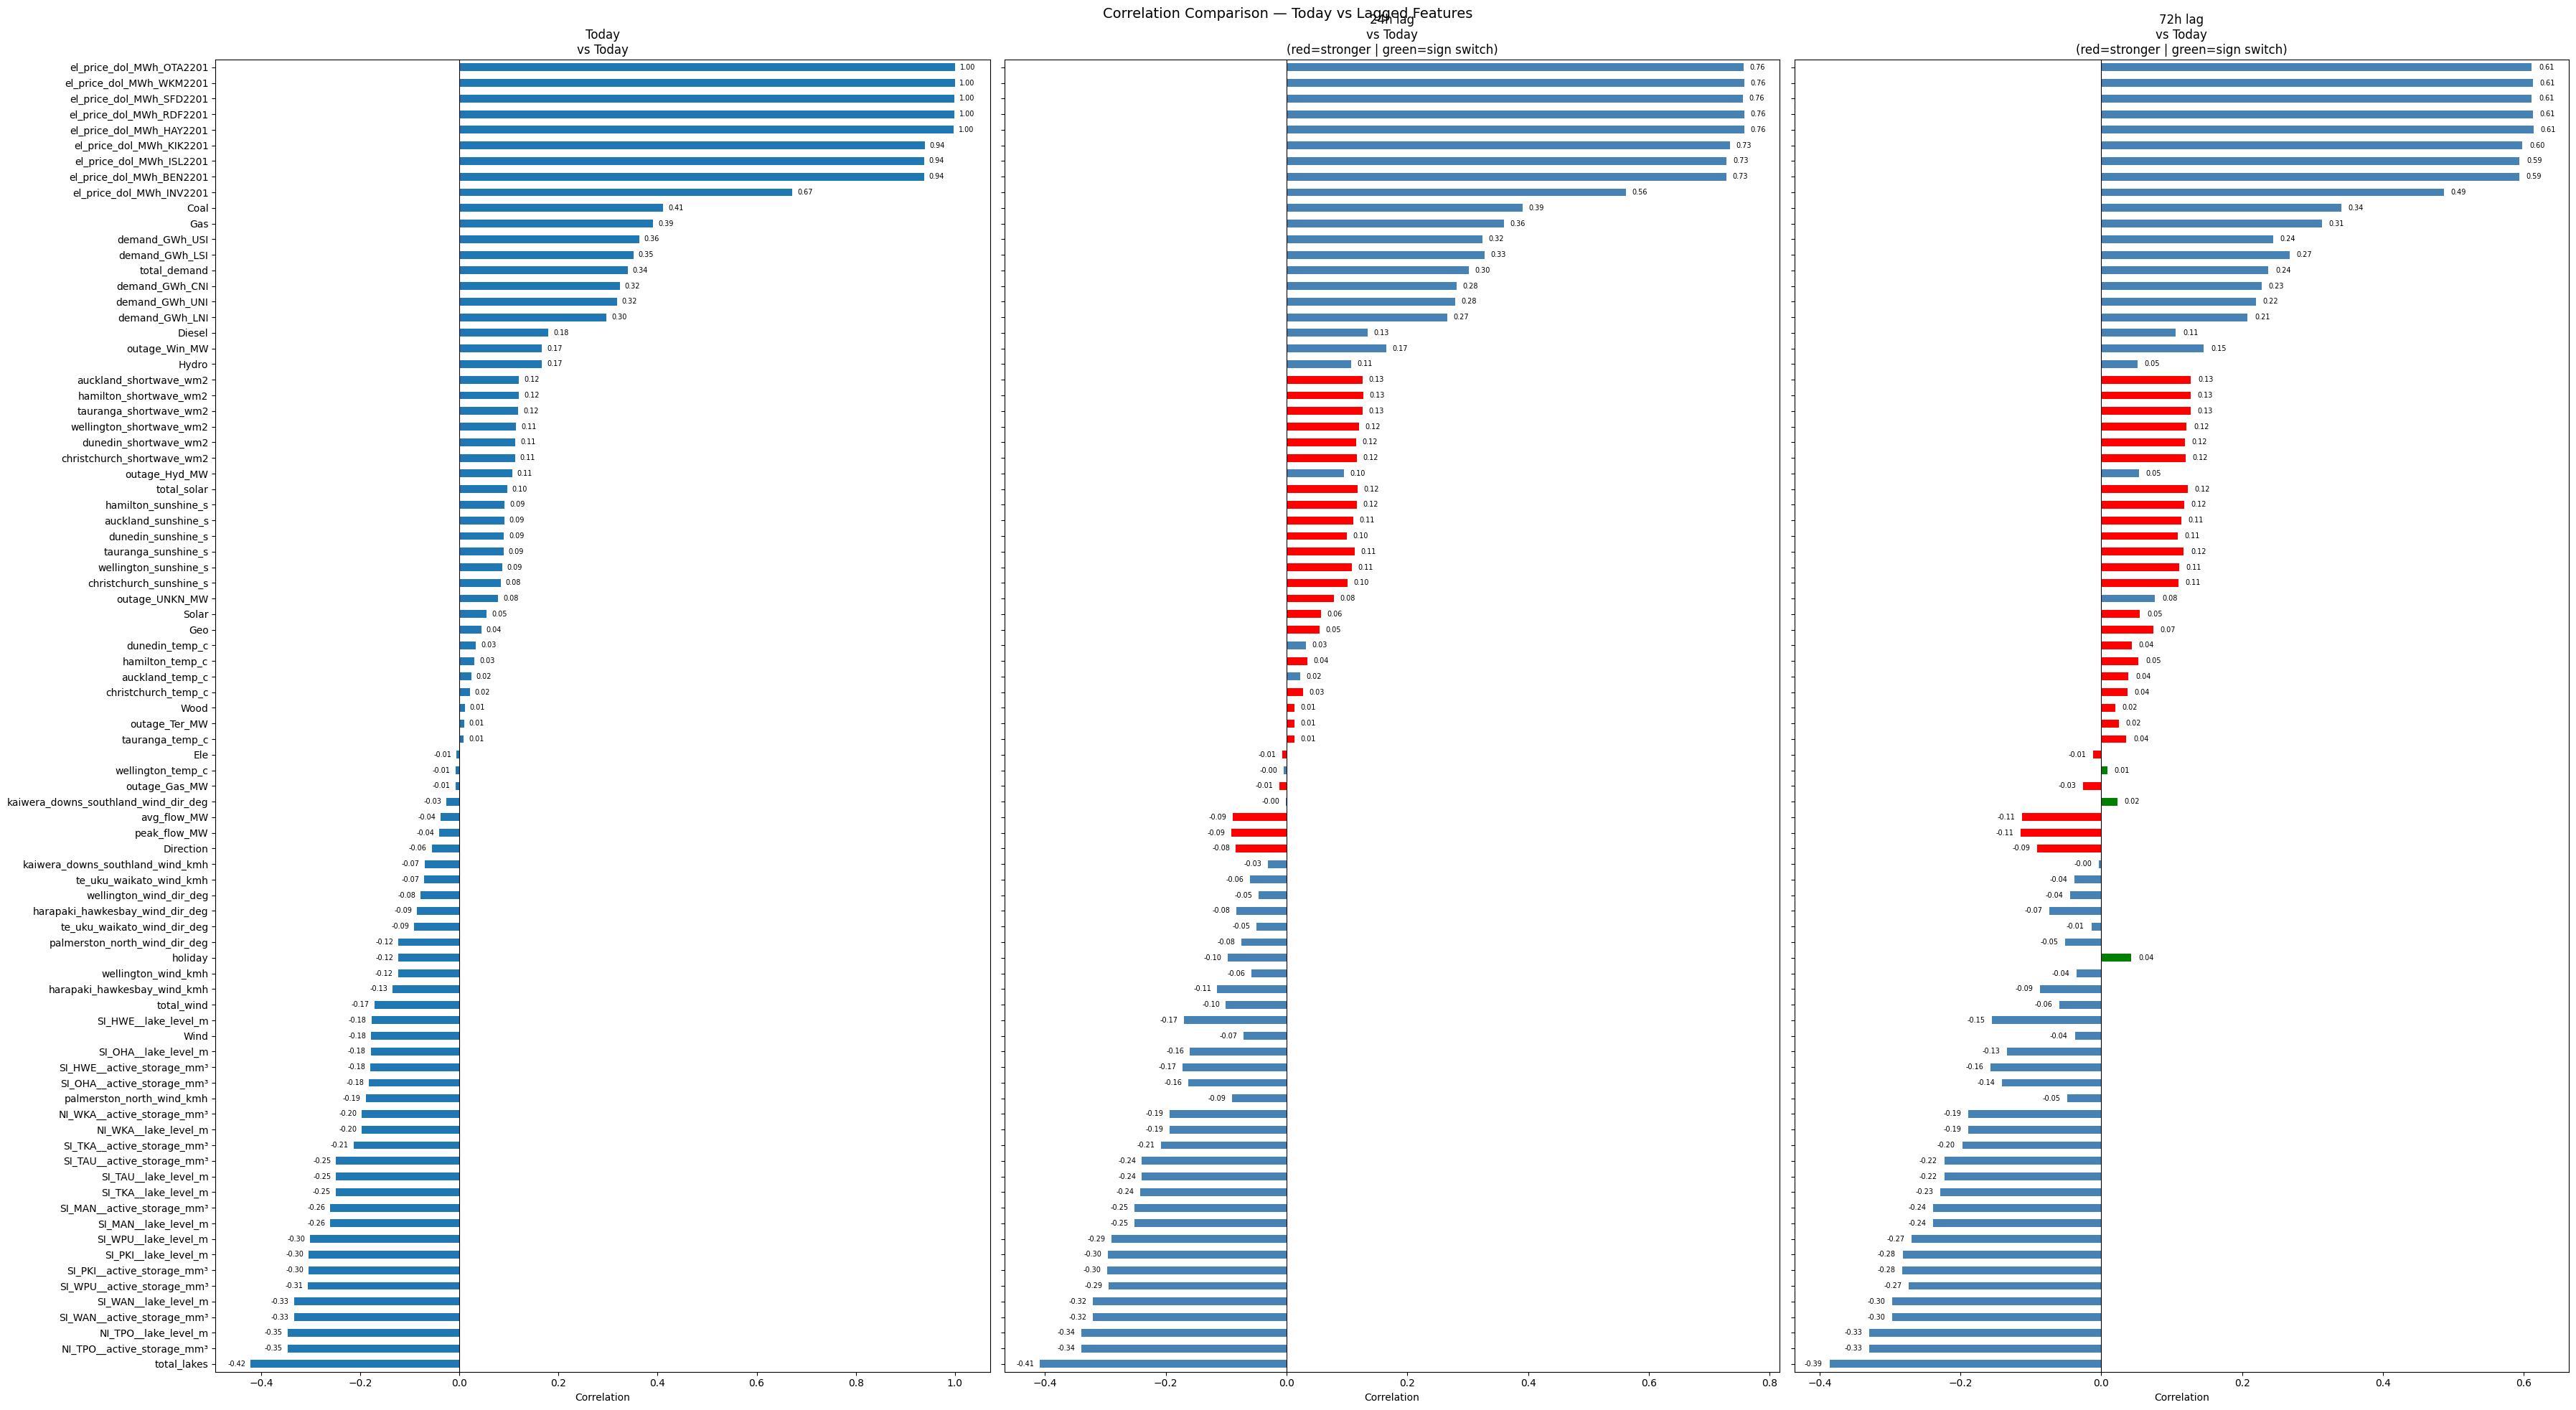

In [12]:
numeric_df = df.select_dtypes(include='number')

# --- Today correlation (anchor for all comparisons) ---
df_today = numeric_df.copy()
df_today[target] = df[target]
corr_today = df_today.corr()[target].sort_values()   # ← removed .drop(target)

# --- Lag configs ---
lag_configs = {
    '24h lag':  24,
    '72h lag':  72,
}

# --- Output DataFrames ---
corr_24  = None
corr_72  = None
output_map = {}  # will populate below

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(36, 20), sharey=True)

# Plot Today on first axis
corr_today.plot(kind='barh', ax=axes[0])
for i, value in enumerate(corr_today):
    axes[0].text(
        value + (0.01 if value >= 0 else -0.01),
        i, f'{value:.2f}',
        va='center', ha='left' if value >= 0 else 'right', fontsize=7
    )
axes[0].set_title('Today\nvs Today')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Correlation')

# --- Loop over lags ---
for ax, (lag_label, lag_hours) in zip(axes[1:], lag_configs.items()):

    # Compute lagged correlation
    df_lagged = numeric_df.shift(lag_hours).copy()
    df_lagged['_y_now_'] = df[target]                  # ← aux column, leaves lagged target intact
    corr_lagged = df_lagged.corr()['_y_now_'].drop('_y_now_')

    # Align to today's order
    corr_lagged_aligned = corr_lagged[corr_today.index]

    # --- Flags ---
    sign_switch  = (corr_today * corr_lagged_aligned) < 0
    abs_improved = (corr_lagged_aligned.abs() > corr_today.abs()) & ~sign_switch

    # --- Colors ---
    colors = []
    for feat in corr_today.index:
        if sign_switch[feat]:
            colors.append('green')
        elif abs_improved[feat]:
            colors.append('red')
        else:
            colors.append('steelblue')

    # --- Plot lag chart ---
    corr_lagged_aligned.plot(kind='barh', ax=ax, color=colors)
    for i, value in enumerate(corr_lagged_aligned):
        ax.text(
            value + (0.01 if value >= 0 else -0.01),
            i, f'{value:.2f}',
            va='center', ha='left' if value >= 0 else 'right', fontsize=7
        )
    ax.set_title(f'{lag_label}\nvs Today\n(red=stronger | green=sign switch)')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Correlation')

    # --- Build summary DataFrame (flagged features only) ---
    flagged = abs_improved | sign_switch

    summary = pd.DataFrame({
        'feature':        corr_today.index[flagged],
        'corr_today':     corr_today[flagged].values,
        f'corr_{lag_hours}h': corr_lagged_aligned[flagged].values,
    }).assign(
        abs_change = lambda x: (x[f'corr_{lag_hours}h'].abs() - x['corr_today'].abs()),
        pct_change = lambda x: ((x[f'corr_{lag_hours}h'].abs() - x['corr_today'].abs()) / x['corr_today'].abs() * 100).round(2),
        flag       = lambda x: x.apply(
            lambda r: 'sign_switch' if (r['corr_today'] * r[f'corr_{lag_hours}h']) < 0 else 'abs_improved', axis=1
        )
    ).sort_values('abs_change', ascending=False).reset_index(drop=True)

    summary = summary[['feature', 'corr_today', f'corr_{lag_hours}h', 'abs_change', 'pct_change', 'flag']]

    output_map[lag_hours] = summary

plt.suptitle('Correlation Comparison — Today vs Lagged Features', fontsize=14)
plt.tight_layout()
plt.show()

# --- Assign to named variables ---
corr_24  = output_map[24]
corr_72  = output_map[72]


# --- All features (flagged + unchanged) ---
for lag_hours in [24, 72]:
    df_lagged_all = numeric_df.shift(lag_hours).copy()
    df_lagged_all['_y_now_'] = df[target]
    corr_lagged_aligned = (
        df_lagged_all.corr()['_y_now_']
        .drop('_y_now_')
        [corr_today.index]
    )

    all_df = pd.DataFrame({
        'feature':            corr_today.index,
        'corr_today':         corr_today.values,
        f'corr_{lag_hours}h': corr_lagged_aligned.values,
    }).assign(
        abs_change = lambda x: (x[f'corr_{lag_hours}h'].abs() - x['corr_today'].abs()),
        pct_change = lambda x: ((x[f'corr_{lag_hours}h'].abs() - x['corr_today'].abs()) / x['corr_today'].abs() * 100).round(2),
        flag       = lambda x: x.apply(
            lambda r: 'sign_switch' if (r['corr_today'] * r[f'corr_{lag_hours}h']) < 0
                      else ('abs_improved' if abs(r[f'corr_{lag_hours}h']) > abs(r['corr_today'])
                      else 'unchanged'), axis=1
        )
    ).sort_values('abs_change', ascending=False).reset_index(drop=True)

    if lag_hours == 24:
        corr_24_all = all_df
    else:
        corr_72_all = all_df


# --- Print summaries ---
# for hours, df_out in [(24, corr_24), (72, corr_72), (168, corr_168), (336, corr_336)]:
#     flagged_count = len(df_out)
#     improved = (df_out['flag'] == 'abs_improved').sum()
#     switched = (df_out['flag'] == 'sign_switch').sum()
#     print(f'\ncorr_{hours}h — {flagged_count} flagged ({improved} stronger, {switched} sign switches):')
#     print(df_out.to_string(index=False))

#### 168h & 336h Lagged Correlation

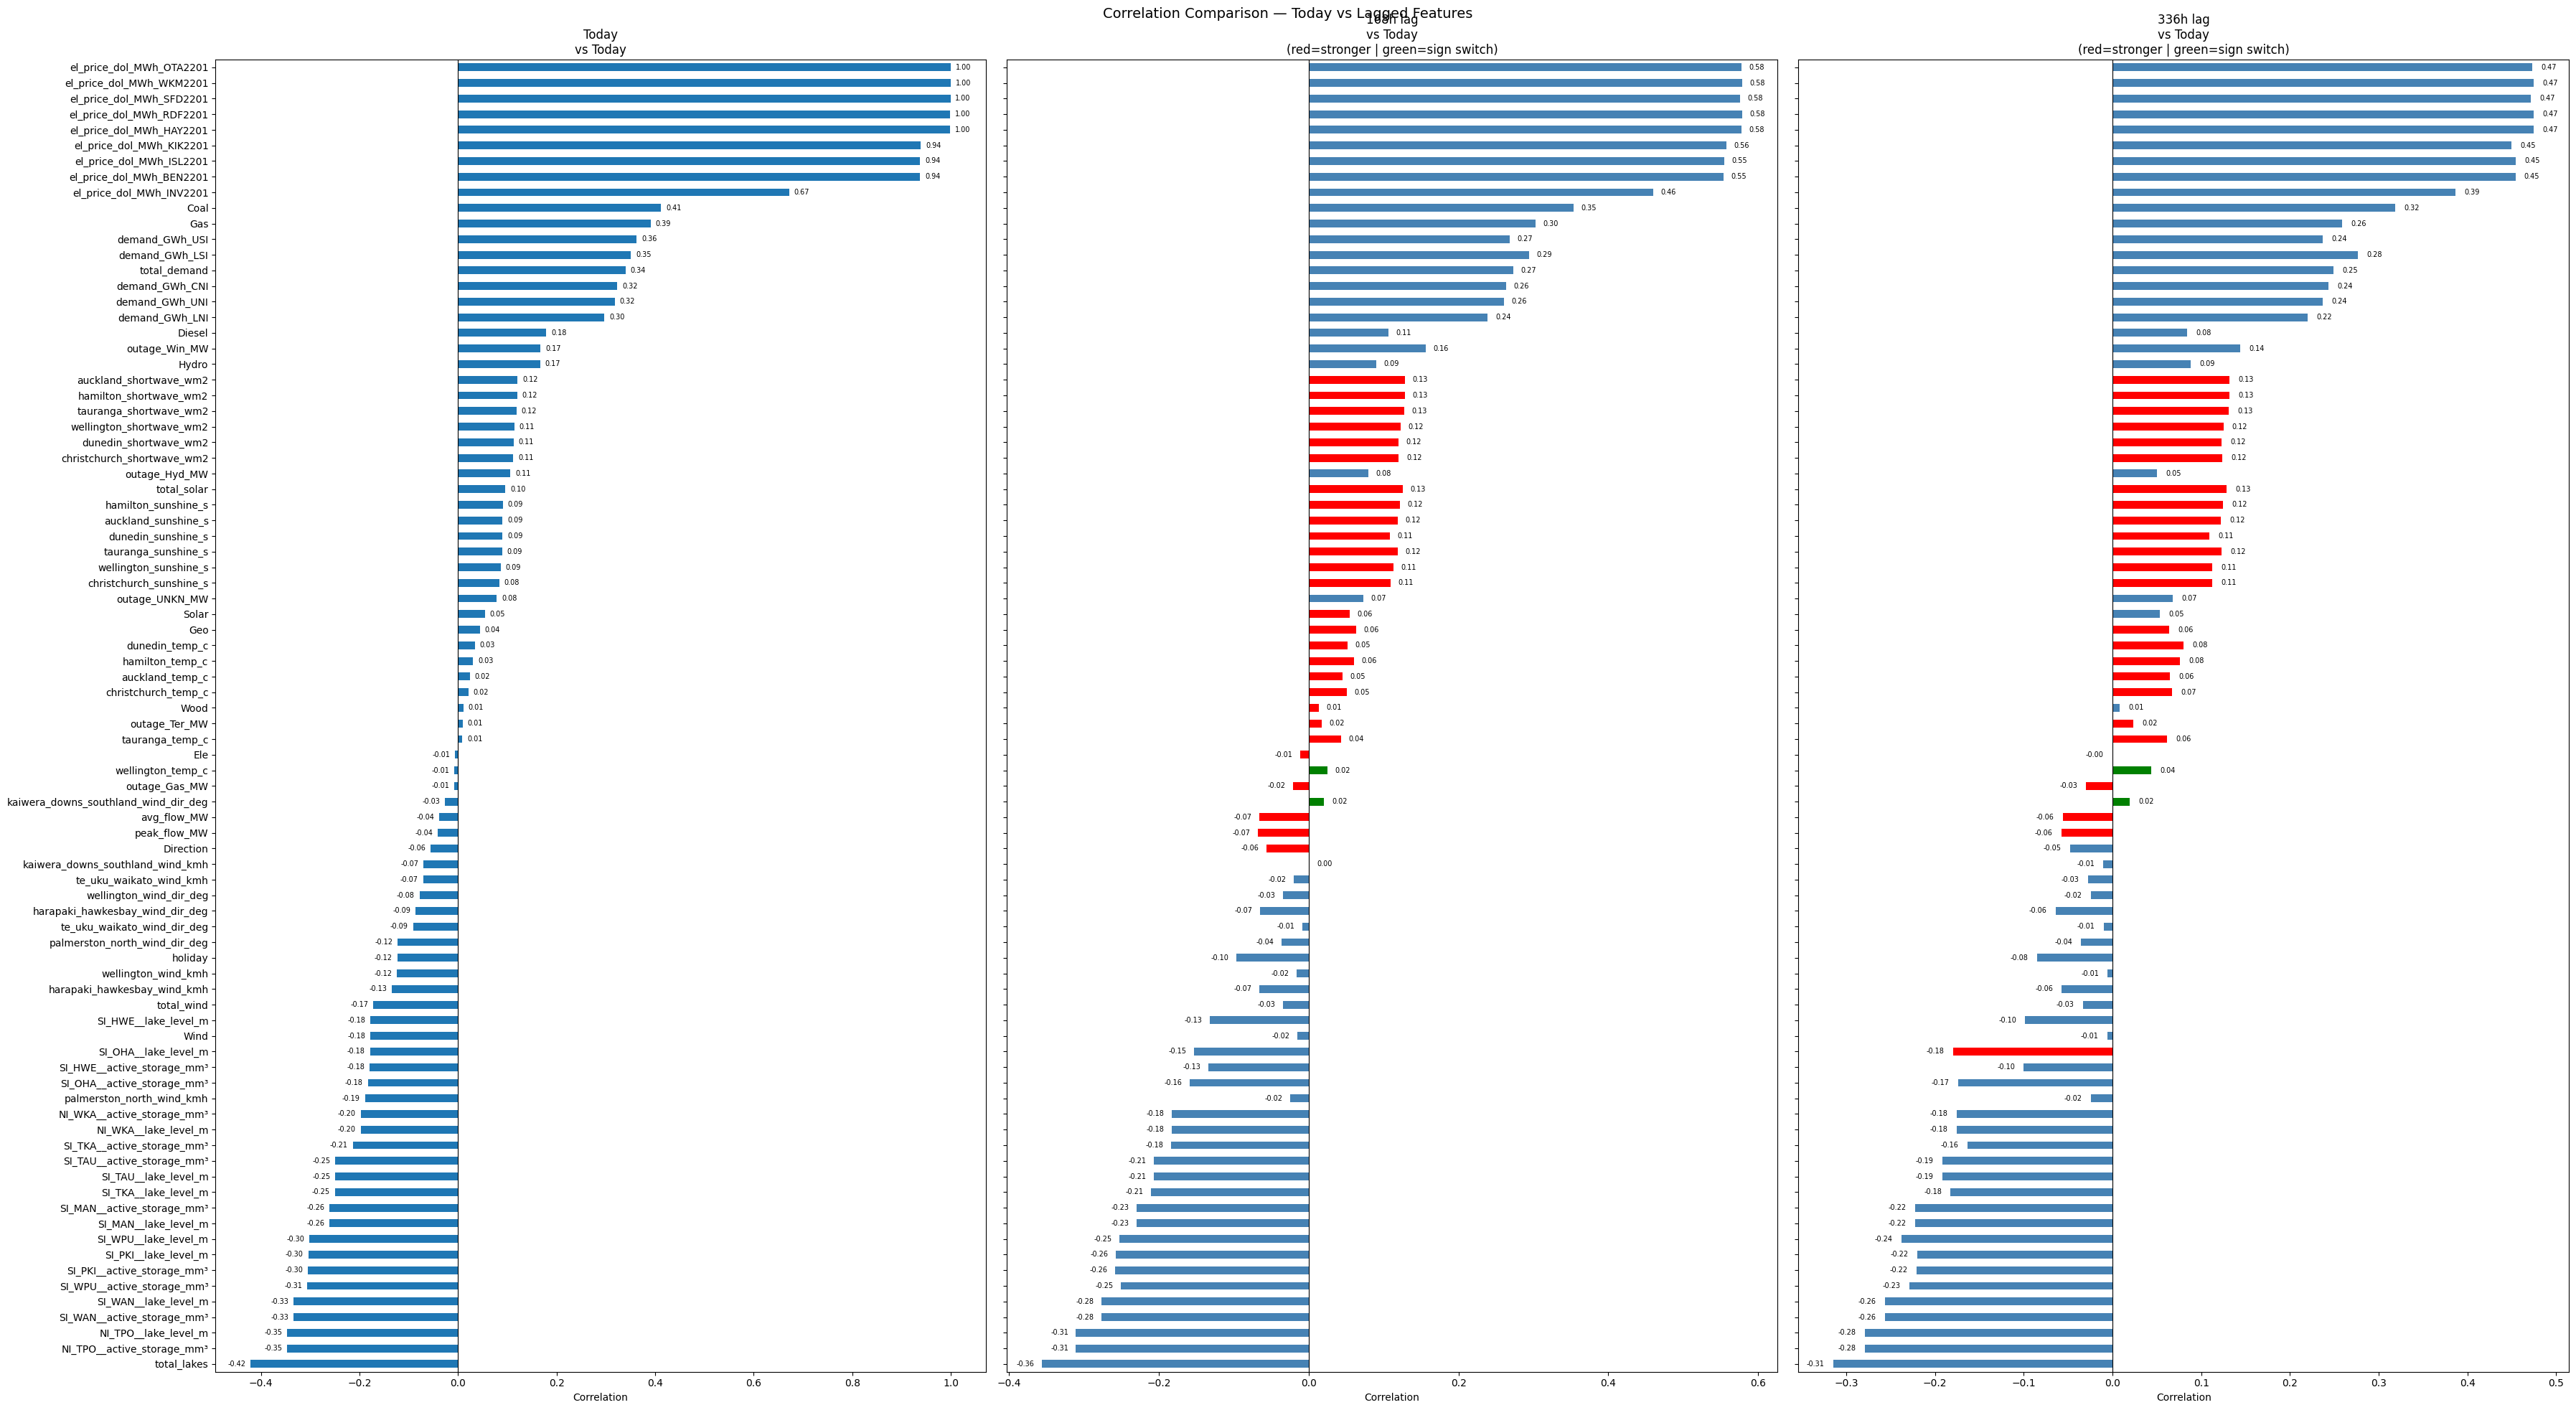

In [13]:

numeric_df = df.select_dtypes(include='number')

# --- Today correlation (anchor for all comparisons) ---
df_today = numeric_df.copy()
df_today[target] = df[target]
corr_today = df_today.corr()[target].sort_values()   # ← removed .drop(target)

# --- Lag configs ---
lag_configs = {
    '168h lag': 168,
    '336h lag': 336
}

# --- Output DataFrames ---
corr_168 = None
corr_336 = None
output_map = {}  # will populate below

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(36, 20), sharey=True)

# Plot Today on first axis
corr_today.plot(kind='barh', ax=axes[0])
for i, value in enumerate(corr_today):
    axes[0].text(
        value + (0.01 if value >= 0 else -0.01),
        i, f'{value:.2f}',
        va='center', ha='left' if value >= 0 else 'right', fontsize=7
    )
axes[0].set_title('Today\nvs Today')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Correlation')

# --- Loop over lags ---
for ax, (lag_label, lag_hours) in zip(axes[1:], lag_configs.items()):

    # Compute lagged correlation
    df_lagged = numeric_df.shift(lag_hours).copy()
    df_lagged['_y_now_'] = df[target]                  # ← aux column, leaves lagged target intact
    corr_lagged = df_lagged.corr()['_y_now_'].drop('_y_now_')

    # Align to today's order
    corr_lagged_aligned = corr_lagged[corr_today.index]

    # --- Flags ---
    sign_switch  = (corr_today * corr_lagged_aligned) < 0
    abs_improved = (corr_lagged_aligned.abs() > corr_today.abs()) & ~sign_switch

    # --- Colors ---
    colors = []
    for feat in corr_today.index:
        if sign_switch[feat]:
            colors.append('green')
        elif abs_improved[feat]:
            colors.append('red')
        else:
            colors.append('steelblue')

    # --- Plot lag chart ---
    corr_lagged_aligned.plot(kind='barh', ax=ax, color=colors)
    for i, value in enumerate(corr_lagged_aligned):
        ax.text(
            value + (0.01 if value >= 0 else -0.01),
            i, f'{value:.2f}',
            va='center', ha='left' if value >= 0 else 'right', fontsize=7
        )
    ax.set_title(f'{lag_label}\nvs Today\n(red=stronger | green=sign switch)')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Correlation')

    # --- Build summary DataFrame (flagged features only) ---
    flagged = abs_improved | sign_switch

    summary = pd.DataFrame({
        'feature':        corr_today.index[flagged],
        'corr_today':     corr_today[flagged].values,
        f'corr_{lag_hours}h': corr_lagged_aligned[flagged].values,
    }).assign(
        abs_change = lambda x: (x[f'corr_{lag_hours}h'].abs() - x['corr_today'].abs()),
        pct_change = lambda x: ((x[f'corr_{lag_hours}h'].abs() - x['corr_today'].abs()) / x['corr_today'].abs() * 100).round(2),
        flag       = lambda x: x.apply(
            lambda r: 'sign_switch' if (r['corr_today'] * r[f'corr_{lag_hours}h']) < 0 else 'abs_improved', axis=1
        )
    ).sort_values('abs_change', ascending=False).reset_index(drop=True)

    summary = summary[['feature', 'corr_today', f'corr_{lag_hours}h', 'abs_change', 'pct_change', 'flag']]

    output_map[lag_hours] = summary

plt.suptitle('Correlation Comparison — Today vs Lagged Features', fontsize=14)
plt.tight_layout()
plt.show()

# --- Assign to named variables ---
corr_168 = output_map[168]
corr_336 = output_map[336]

# --- All features (flagged + unchanged) ---
for lag_hours in [168, 336]:
    df_lagged_all = numeric_df.shift(lag_hours).copy()
    df_lagged_all['_y_now_'] = df[target]
    corr_lagged_aligned = (
        df_lagged_all.corr()['_y_now_']
        .drop('_y_now_')
        [corr_today.index]
    )

    all_df = pd.DataFrame({
        'feature':            corr_today.index,
        'corr_today':         corr_today.values,
        f'corr_{lag_hours}h': corr_lagged_aligned.values,
    }).assign(
        abs_change = lambda x: (x[f'corr_{lag_hours}h'].abs() - x['corr_today'].abs()),
        pct_change = lambda x: ((x[f'corr_{lag_hours}h'].abs() - x['corr_today'].abs()) / x['corr_today'].abs() * 100).round(2),
        flag       = lambda x: x.apply(
            lambda r: 'sign_switch' if (r['corr_today'] * r[f'corr_{lag_hours}h']) < 0
                      else ('abs_improved' if abs(r[f'corr_{lag_hours}h']) > abs(r['corr_today'])
                      else 'unchanged'), axis=1
        )
    ).sort_values('abs_change', ascending=False).reset_index(drop=True)

    if lag_hours == 168:
        corr_168_all = all_df
    else:
        corr_336_all = all_df

# --- Print summaries ---
# for hours, df_out in [(24, corr_24), (72, corr_72), (168, corr_168), (336, corr_336)]:
#     flagged_count = len(df_out)
#     improved = (df_out['flag'] == 'abs_improved').sum()
#     switched = (df_out['flag'] == 'sign_switch').sum()
#     print(f'\ncorr_{hours}h — {flagged_count} flagged ({improved} stronger, {switched} sign switches):')
#     print(df_out.to_string(index=False))

#### 7 Day Moving Average Lagged Correlation

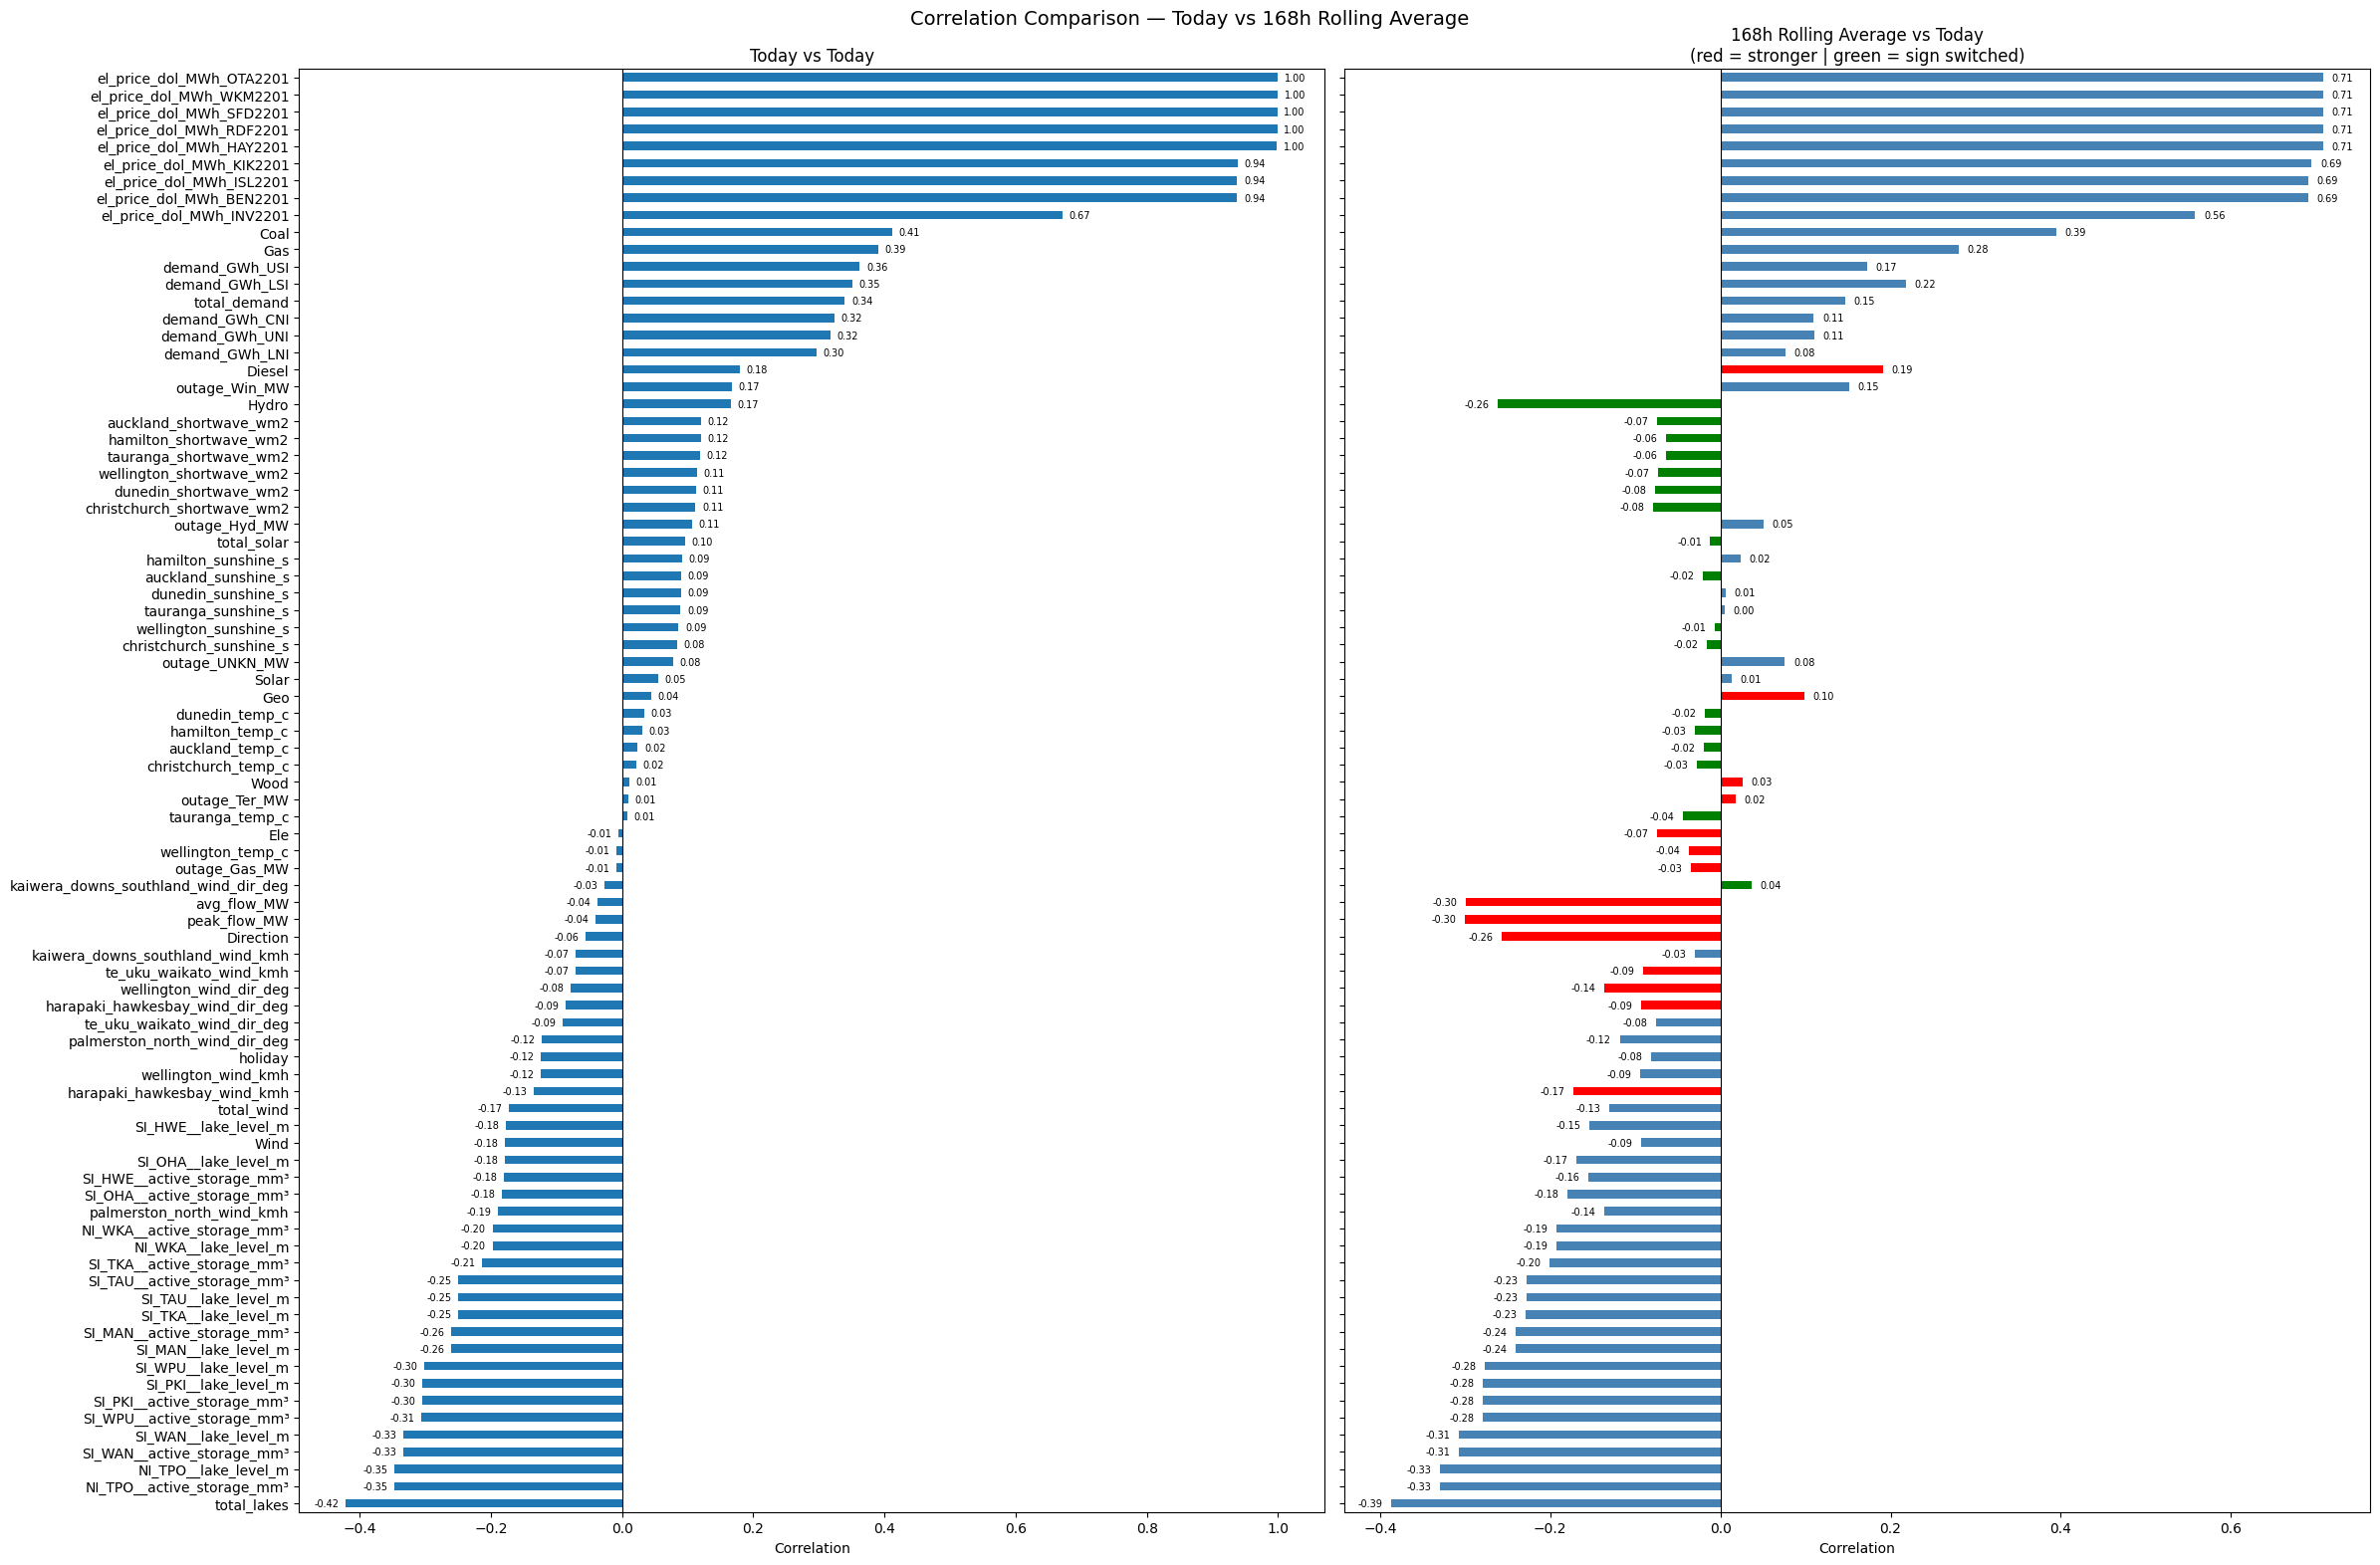

In [14]:

numeric_df = df.select_dtypes(include='number')

# --- Compute both correlations ---
df_today = numeric_df.copy()
df_today[target] = df[target]
corr_today = df_today.corr()[target].sort_values()   # ← removed .drop(target)

df_rolling = numeric_df.shift(1).rolling(window=168).mean()
df_rolling['_y_now_'] = df[target]                                   # ← aux, doesn't overwrite rolling target
corr_rolling = df_rolling.corr()['_y_now_'].drop('_y_now_')

# Align rolling to today's order
corr_rolling_aligned = corr_rolling[corr_today.index]

# --- Flags ---
sign_switch  = (corr_today * corr_rolling_aligned) < 0                        # green: sign flipped
abs_improved = (corr_rolling_aligned.abs() > corr_today.abs()) & ~sign_switch  # red: stronger, same sign

# --- Colors ---
colors = []
for feat in corr_today.index:
    if sign_switch[feat]:
        colors.append('green')
    elif abs_improved[feat]:
        colors.append('red')
    else:
        colors.append('steelblue')

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(24, 16), sharey=True)

# Today chart
corr_today.plot(kind='barh', ax=axes[0])
for i, value in enumerate(corr_today):
    axes[0].text(
        value + (0.01 if value >= 0 else -0.01),
        i, f'{value:.2f}',
        va='center', ha='left' if value >= 0 else 'right', fontsize=7
    )
axes[0].set_title('Today vs Today')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Correlation')

# Rolling chart
corr_rolling_aligned.plot(kind='barh', ax=axes[1], color=colors)
for i, value in enumerate(corr_rolling_aligned):
    axes[1].text(
        value + (0.01 if value >= 0 else -0.01),
        i, f'{value:.2f}',
        va='center', ha='left' if value >= 0 else 'right', fontsize=7
    )
axes[1].set_title('168h Rolling Average vs Today\n(red = stronger | green = sign switched)')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Correlation')

plt.suptitle('Correlation Comparison — Today vs 168h Rolling Average', fontsize=14)
plt.tight_layout()
plt.show()

# --- Summary DataFrame (red + green features) ---
flagged = abs_improved | sign_switch

summary = pd.DataFrame({
    'feature':          corr_today.index[flagged],
    'corr_today':       corr_today[flagged].values,
    'corr_rolling_168': corr_rolling_aligned[flagged].values,
}).assign(
    abs_change = lambda x: (x['corr_rolling_168'].abs() - x['corr_today'].abs()),
    pct_change = lambda x: ((x['corr_rolling_168'].abs() - x['corr_today'].abs()) / x['corr_today'].abs() * 100).round(2),
    flag       = lambda x: x.apply(
        lambda r: 'sign_switch' if (r['corr_today'] * r['corr_rolling_168']) < 0 else 'abs_improved', axis=1
    )
).sort_values('abs_change', ascending=False).reset_index(drop=True)

# Reorder columns
summary = summary[['feature', 'corr_today', 'corr_rolling_168', 'abs_change', 'pct_change', 'flag']]
corr_rolling_168 = summary

# Get all correlations
corr_rolling_168_all = pd.DataFrame({
    'feature':          corr_today.index,
    'corr_today':       corr_today.values,
    'corr_rolling_168': corr_rolling_aligned.values,
}).assign(
    abs_change = lambda x: (x['corr_rolling_168'].abs() - x['corr_today'].abs()),
    pct_change = lambda x: ((x['corr_rolling_168'].abs() - x['corr_today'].abs()) / x['corr_today'].abs() * 100).round(2),
    flag       = lambda x: x.apply(
        lambda r: 'sign_switch' if (r['corr_today'] * r['corr_rolling_168']) < 0
                  else ('abs_improved' if abs(r['corr_rolling_168']) > abs(r['corr_today'])
                  else 'unchanged'), axis=1
    )
).sort_values('abs_change', ascending=False).reset_index(drop=True)

# print(f'{len(summary)} features flagged ({abs_improved.sum()} stronger, {sign_switch.sum()} sign switches):\n')
# print(summary.to_string(index=False))

#### 3 Day Moving Average Lagged Correlation

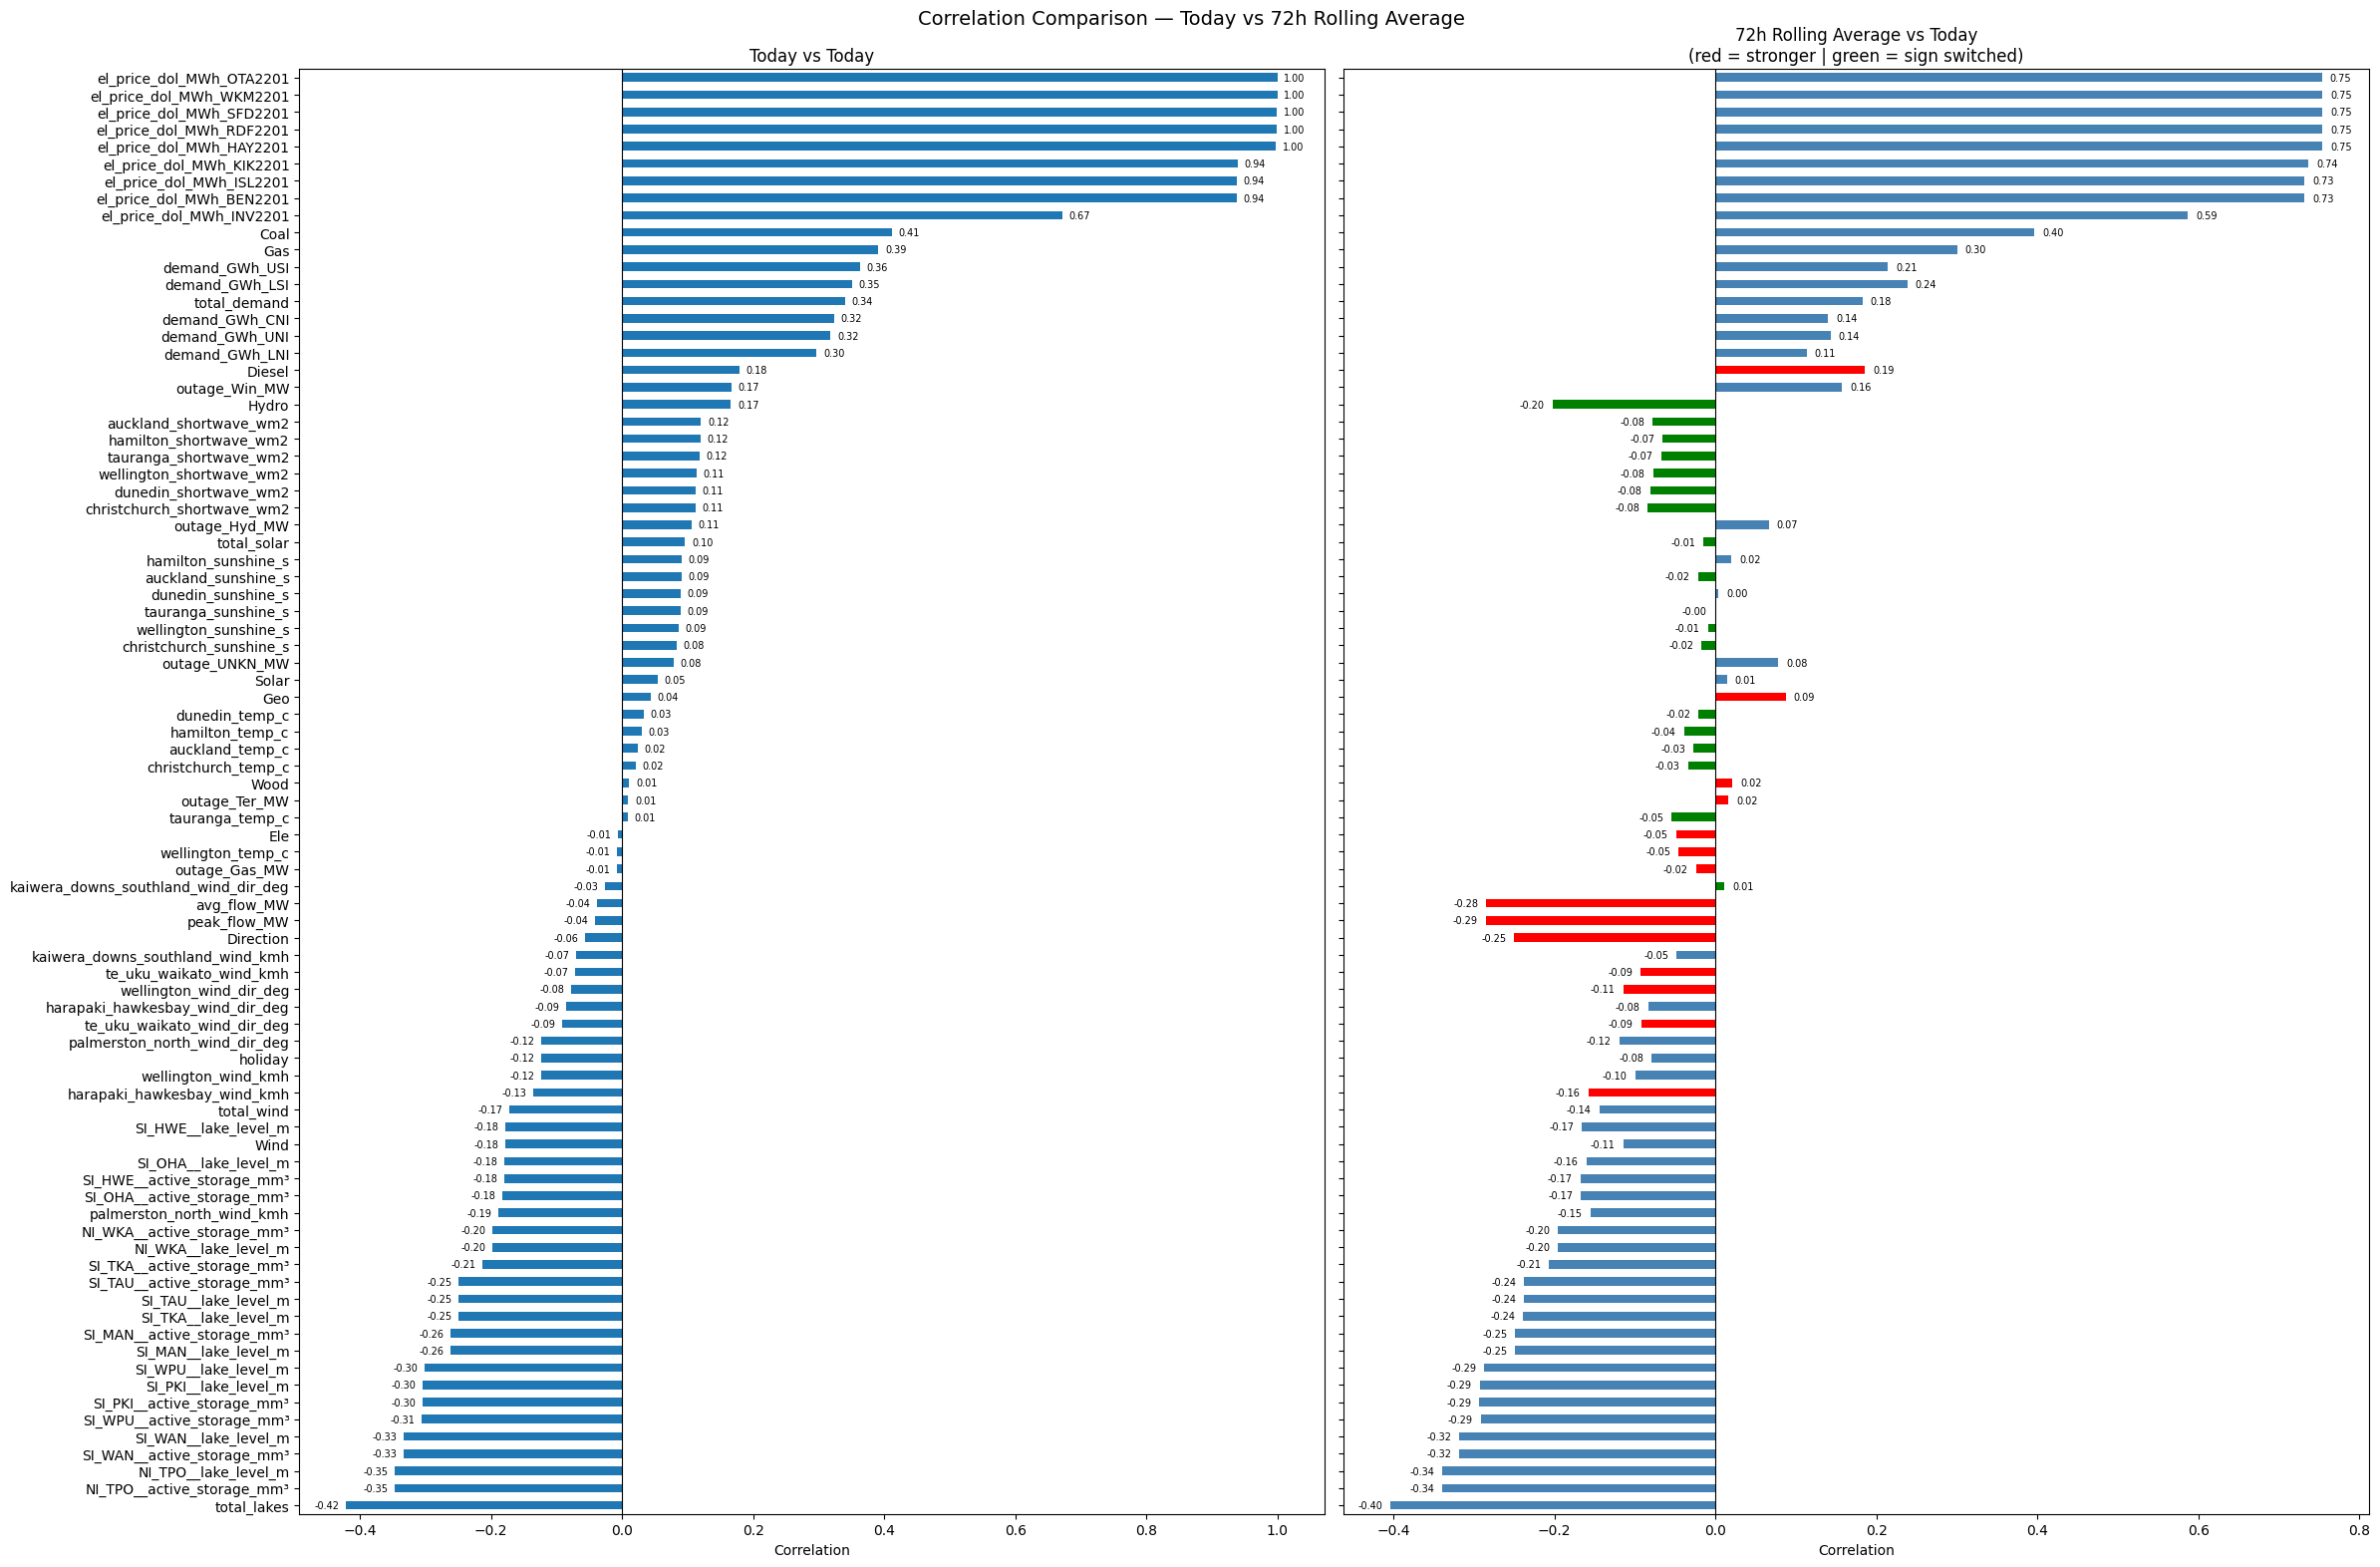

In [15]:
numeric_df = df.select_dtypes(include='number')

# --- Compute both correlations ---
df_today = numeric_df.copy()
df_today[target] = df[target]
corr_today = df_today.corr()[target].sort_values()   # ← removed .drop(target)

df_rolling = numeric_df.shift(1).rolling(window=72).mean()
df_rolling['_y_now_'] = df[target]                                   # ← aux, doesn't overwrite rolling target
corr_rolling = df_rolling.corr()['_y_now_'].drop('_y_now_')

# Align rolling to today's order
corr_rolling_aligned = corr_rolling[corr_today.index]

# --- Flags ---
sign_switch  = (corr_today * corr_rolling_aligned) < 0
abs_improved = (corr_rolling_aligned.abs() > corr_today.abs()) & ~sign_switch

# --- Colors ---
colors = []
for feat in corr_today.index:
    if sign_switch[feat]:
        colors.append('green')
    elif abs_improved[feat]:
        colors.append('red')
    else:
        colors.append('steelblue')

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(24, 16), sharey=True)

corr_today.plot(kind='barh', ax=axes[0])
for i, value in enumerate(corr_today):
    axes[0].text(
        value + (0.01 if value >= 0 else -0.01),
        i, f'{value:.2f}',
        va='center', ha='left' if value >= 0 else 'right', fontsize=7
    )
axes[0].set_title('Today vs Today')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Correlation')

corr_rolling_aligned.plot(kind='barh', ax=axes[1], color=colors)
for i, value in enumerate(corr_rolling_aligned):
    axes[1].text(
        value + (0.01 if value >= 0 else -0.01),
        i, f'{value:.2f}',
        va='center', ha='left' if value >= 0 else 'right', fontsize=7
    )
axes[1].set_title('72h Rolling Average vs Today\n(red = stronger | green = sign switched)')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Correlation')

plt.suptitle('Correlation Comparison — Today vs 72h Rolling Average', fontsize=14)
plt.tight_layout()
plt.show()

# --- Summary DataFrame (red + green features) ---
flagged = abs_improved | sign_switch

summary = pd.DataFrame({
    'feature':         corr_today.index[flagged],
    'corr_today':      corr_today[flagged].values,
    'corr_rolling_72': corr_rolling_aligned[flagged].values,
}).assign(
    abs_change = lambda x: (x['corr_rolling_72'].abs() - x['corr_today'].abs()),
    pct_change = lambda x: ((x['corr_rolling_72'].abs() - x['corr_today'].abs()) / x['corr_today'].abs() * 100).round(2),
    flag       = lambda x: x.apply(
        lambda r: 'sign_switch' if (r['corr_today'] * r['corr_rolling_72']) < 0 else 'abs_improved', axis=1
    )
).sort_values('abs_change', ascending=False).reset_index(drop=True)

summary = summary[['feature', 'corr_today', 'corr_rolling_72', 'abs_change', 'pct_change', 'flag']]
corr_rolling_72 = summary

# --- All features ---
corr_rolling_72_all = pd.DataFrame({
    'feature':         corr_today.index,
    'corr_today':      corr_today.values,
    'corr_rolling_72': corr_rolling_aligned.values,
}).assign(
    abs_change = lambda x: (x['corr_rolling_72'].abs() - x['corr_today'].abs()),
    pct_change = lambda x: ((x['corr_rolling_72'].abs() - x['corr_today'].abs()) / x['corr_today'].abs() * 100).round(2),
    flag       = lambda x: x.apply(
        lambda r: 'sign_switch' if (r['corr_today'] * r['corr_rolling_72']) < 0
                  else ('abs_improved' if abs(r['corr_rolling_72']) > abs(r['corr_today'])
                  else 'unchanged'), axis=1
    )
).sort_values('abs_change', ascending=False).reset_index(drop=True)

### Cell 8 - Feature Selection - Collinearity with Target

In [19]:
cutoff       = 0.20
top_n_lags   = 3      # keep top N lags per feature

all_corr_dfs = {
    'corr_24h':         (corr_24_all,          'corr_24h'),
    'corr_72h':         (corr_72_all,          'corr_72h'),
    'corr_168h':        (corr_168_all,         'corr_168h'),
    'corr_336h':        (corr_336_all,         'corr_336h'),
    'corr_rolling_72':  (corr_rolling_72_all,  'corr_rolling_72'),
    'corr_rolling_168': (corr_rolling_168_all, 'corr_rolling_168'),
}

# --- Collect ALL lag correlations per feature ---
feature_lags = {}   # feat -> list of (lag_name, corr_val)

for lag_name, (df_corr, lag_col) in all_corr_dfs.items():
    for _, row in df_corr.iterrows():
        feat         = row['feature']
        corr_lag_val = row[lag_col]

        if feat not in feature_lags:
            feature_lags[feat] = []
        feature_lags[feat].append((lag_name, corr_lag_val))

# --- For each feature: rank lags by |corr|, keep top N above cutoff ---
rows = []
for feat, lag_list in feature_lags.items():
    # Sort by absolute correlation, descending
    lag_list_sorted = sorted(lag_list, key=lambda x: abs(x[1]), reverse=True)

    # Keep top N that pass the cutoff
    kept = [(lag, corr) for lag, corr in lag_list_sorted[:top_n_lags] if abs(corr) >= cutoff]

    if not kept:
        continue   # feature has no lag passing the cutoff — drop entirely

    for rank, (lag_name, corr_val) in enumerate(kept, start=1):
        rows.append({
            'feature':  feat,
            'rank':     rank,
            'lag':      lag_name,
            'lag_corr': corr_val,
        })

# --- Build DataFrame ---
feature_selection_df = (
    pd.DataFrame(rows)
    .sort_values(['feature', 'rank'])
    .reset_index(drop=True)
)

# --- Build dictionary: feature -> list of {lag, corr} dicts (ranked) ---
feature_selection_dict = {}
for feat, group in feature_selection_df.groupby('feature', sort=False):
    feature_selection_dict[feat] = group[['rank', 'lag', 'lag_corr']].to_dict(orient='records')

# --- Reporting ---
unique_features_kept = feature_selection_df['feature'].nunique()
total_lag_rows       = len(feature_selection_df)
features_dropped     = len(corr_24_all) - unique_features_kept

print(f'Cutoff: |corr| >= {cutoff}, top {top_n_lags} lags per feature')
print(f'Features kept:    {unique_features_kept}')
print(f'Features dropped: {features_dropped}')
print(f'Total lag-rows:   {total_lag_rows}   (each feature contributes up to {top_n_lags} rows)')
print()
feature_selection_df

Cutoff: |corr| >= 0.2, top 3 lags per feature
Features kept:    36
Features dropped: 48
Total lag-rows:   104   (each feature contributes up to 3 rows)



,feature,rank,lag,lag_corr
0,Coal,1,corr_rolling_72,0.396541
1,Coal,2,corr_rolling_168,0.394693
2,Coal,3,corr_24h,0.390987
3,Direction,1,corr_rolling_168,-0.256790
4,Direction,2,corr_rolling_72,-0.249766
...,...,...,...,...
99,total_demand,2,corr_168h,0.273321
100,total_demand,3,corr_336h,0.249340
101,total_lakes,1,corr_24h,-0.407906
102,total_lakes,2,corr_rolling_72,-0.403482


### Cell 9 - Feature Selection - Feature Multicollinearity

Built feature matrix: (96408, 104)
After dropping NaN rows: (57362, 104)


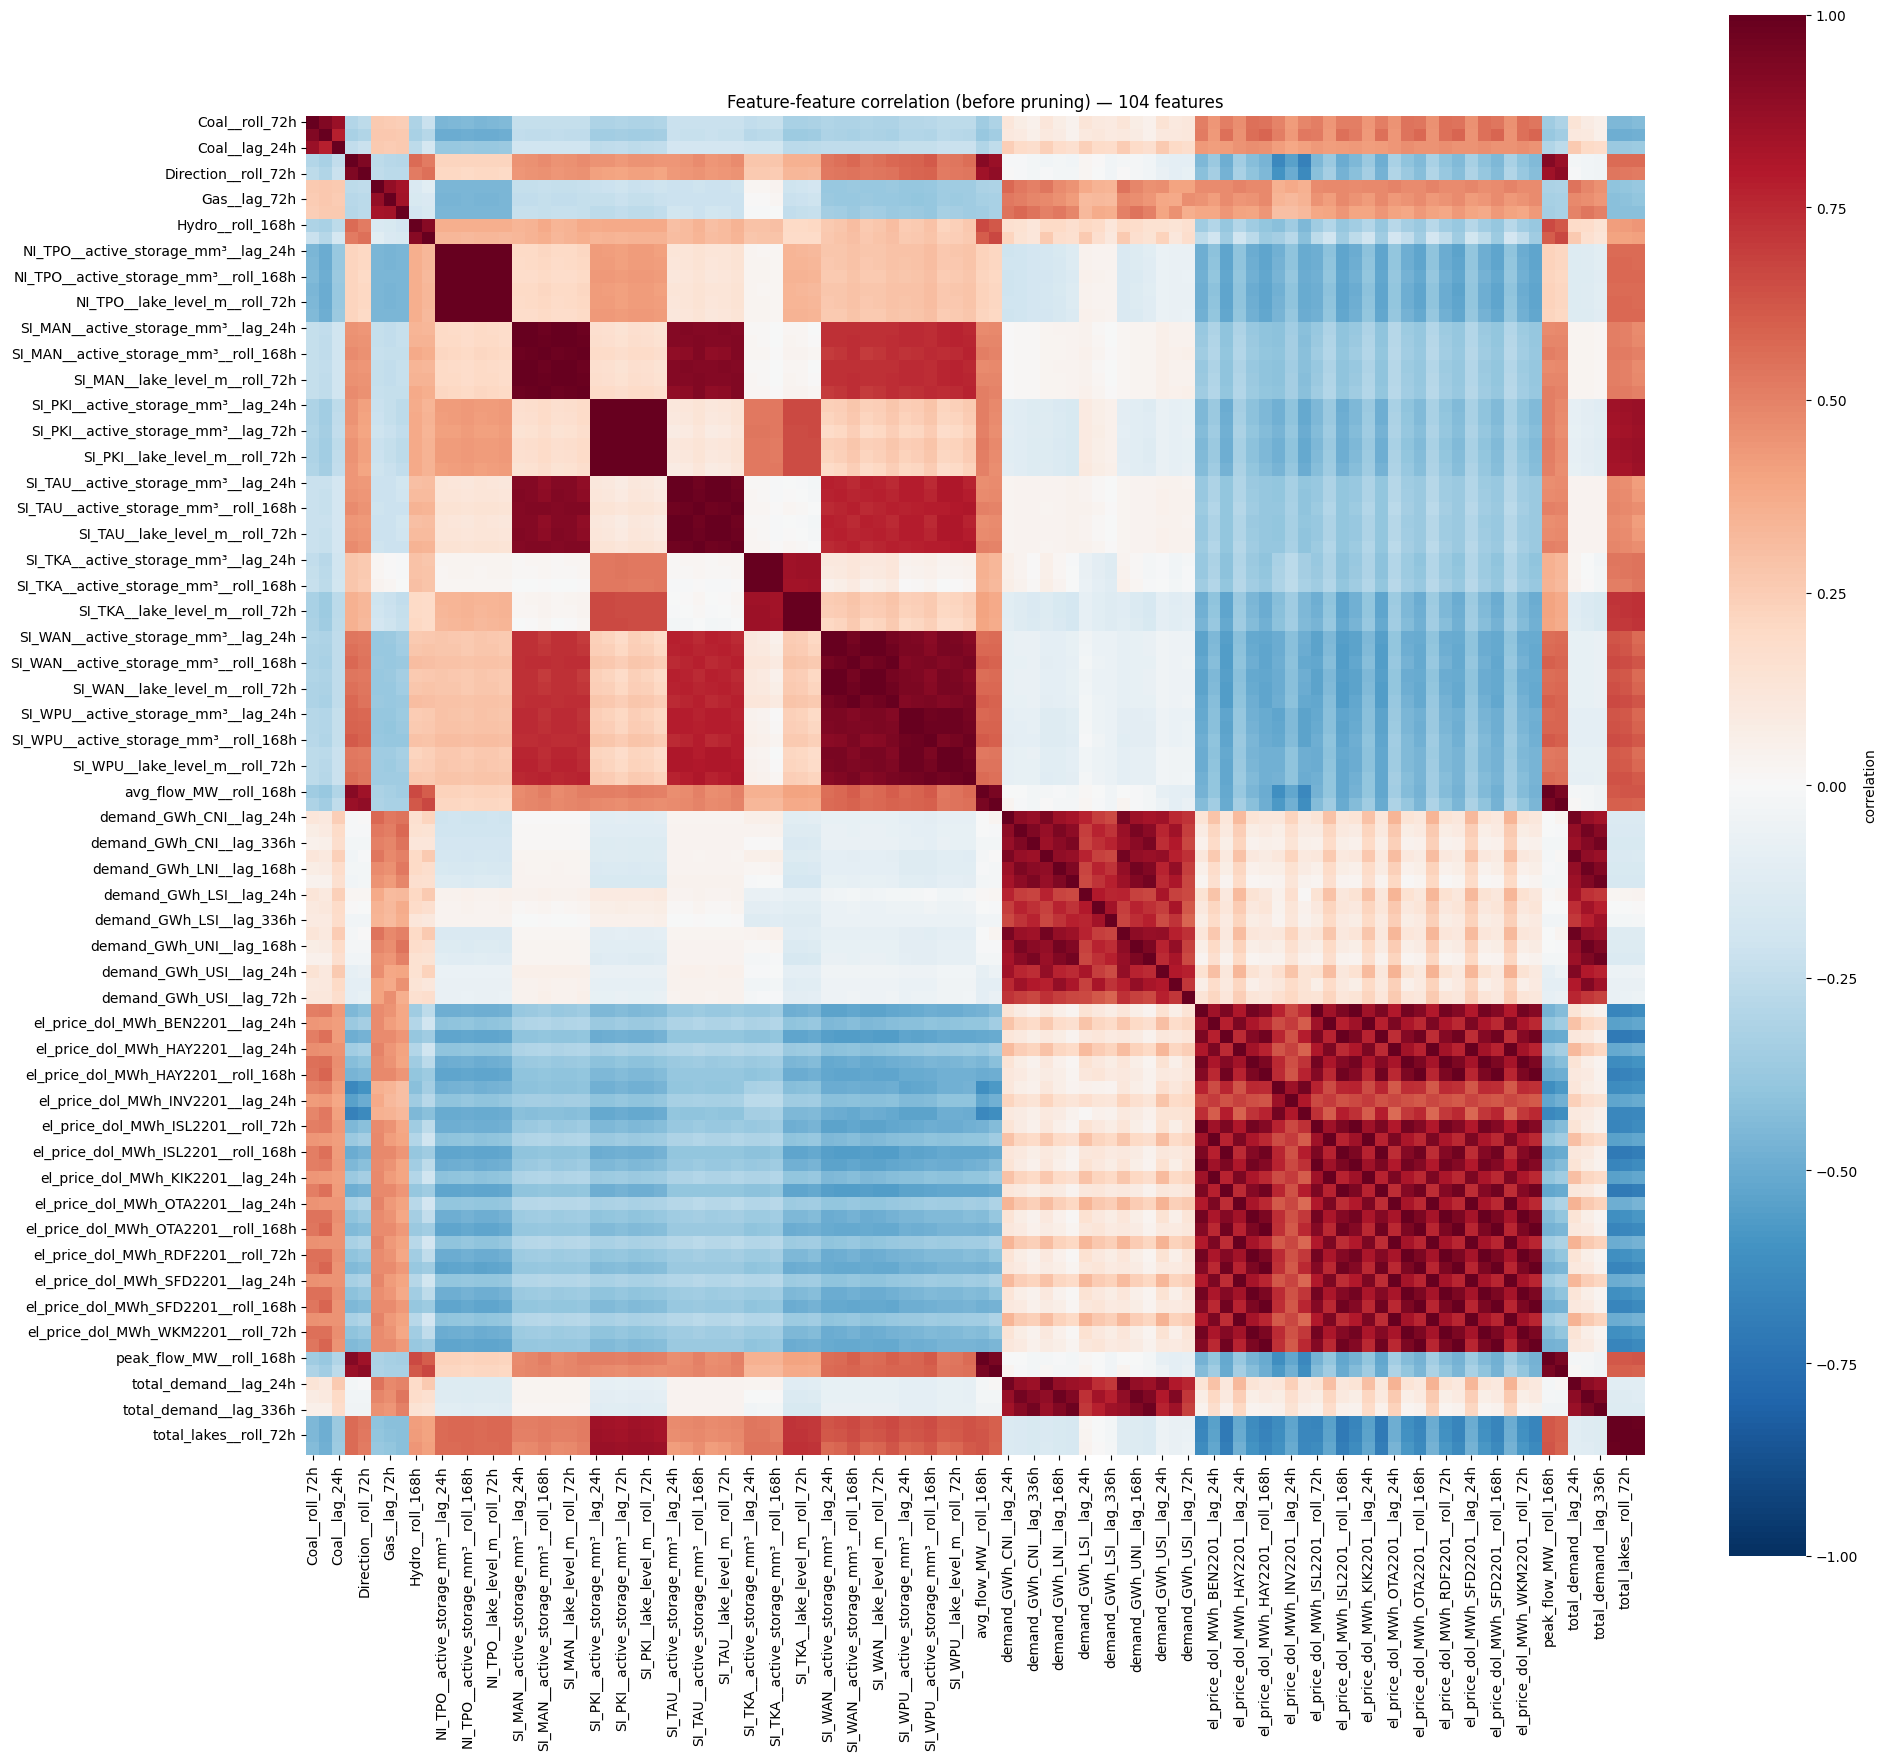


Pairs above |corr| >= 0.9: 356


,feat_a,feat_b,abs_corr
0,SI_MAN__active_storage_mm³__roll_168h,SI_MAN__lake_level_m__roll_168h,1.000000
1,SI_TAU__active_storage_mm³__roll_168h,SI_TAU__lake_level_m__roll_168h,1.000000
2,SI_WAN__active_storage_mm³__roll_168h,SI_WAN__lake_level_m__roll_168h,1.000000
3,SI_MAN__active_storage_mm³__roll_72h,SI_MAN__lake_level_m__roll_72h,1.000000
4,SI_TAU__active_storage_mm³__roll_72h,SI_TAU__lake_level_m__roll_72h,1.000000
5,SI_WAN__active_storage_mm³__roll_72h,SI_WAN__lake_level_m__roll_72h,1.000000
6,NI_TPO__active_storage_mm³__roll_168h,NI_TPO__lake_level_m__roll_168h,1.000000
7,SI_MAN__active_storage_mm³__lag_24h,SI_MAN__lake_level_m__lag_24h,1.000000
8,SI_TAU__active_storage_mm³__lag_24h,SI_TAU__lake_level_m__lag_24h,1.000000
9,SI_WAN__active_storage_mm³__lag_24h,SI_WAN__lake_level_m__lag_24h,1.000000


In [17]:
multicoll_threshold = 0.9   # drop pairs above this

# --- Step 1: Build the lagged feature DataFrame ---
# This creates the actual columns XGBoost will see, one per (feature, lag) pair
# from feature_selection_dict

lag_map = {
    'corr_24h':         ('shift',   24),
    'corr_72h':         ('shift',   72),
    'corr_168h':        ('shift',  168),
    'corr_336h':        ('shift',  336),
    'corr_rolling_72':  ('rolling', 72),
    'corr_rolling_168': ('rolling', 168),
}

lagged_features = {}

for feat, lag_records in feature_selection_dict.items():
    for record in lag_records:
        lag_name = record['lag']
        kind, n  = lag_map[lag_name]

        if kind == 'shift':
            col_name = f'{feat}__lag_{n}h'
            lagged_features[col_name] = df[feat].shift(n)
        else:   # rolling mean
            col_name = f'{feat}__roll_{n}h'
            lagged_features[col_name] = df[feat].shift(1).rolling(window=n).mean()

X_features = pd.DataFrame(lagged_features, index=df.index)
print(f'Built feature matrix: {X_features.shape}')


# --- Step 2: Compute the feature-feature correlation matrix ---
# Drop NaN rows introduced by shifts/rolling (longest lag = 336h)
X_clean = X_features.dropna()
print(f'After dropping NaN rows: {X_clean.shape}')

feat_corr = X_clean.corr().abs()

# Zero out the diagonal and lower triangle so we only see each pair once
upper = feat_corr.where(
    np.triu(np.ones(feat_corr.shape), k=1).astype(bool)
)

# Visualize Multicollinearity
plt.figure(figsize=(20, 18))
sns.heatmap(X_clean.corr(),
            cmap='RdBu_r',
            center=0,
            vmin=-1,
            vmax=1,
            square=True,
            cbar_kws={'label': 'correlation'})
plt.title(f'Feature-feature correlation (before pruning) — {X_clean.shape[1]} features')
plt.tight_layout()
plt.show()


# --- Step 3: Find and rank highly-correlated pairs ---
pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'feat_a', 'level_1': 'feat_b', 0: 'abs_corr'})
    .query('abs_corr >= @multicoll_threshold')
    .sort_values('abs_corr', ascending=False)
    .reset_index(drop=True)
)

print(f'\nPairs above |corr| >= {multicoll_threshold}: {len(pairs)}')
pairs.head(30)

Features to drop: 80
Features to keep: 24
Final feature matrix: (96408, 24)


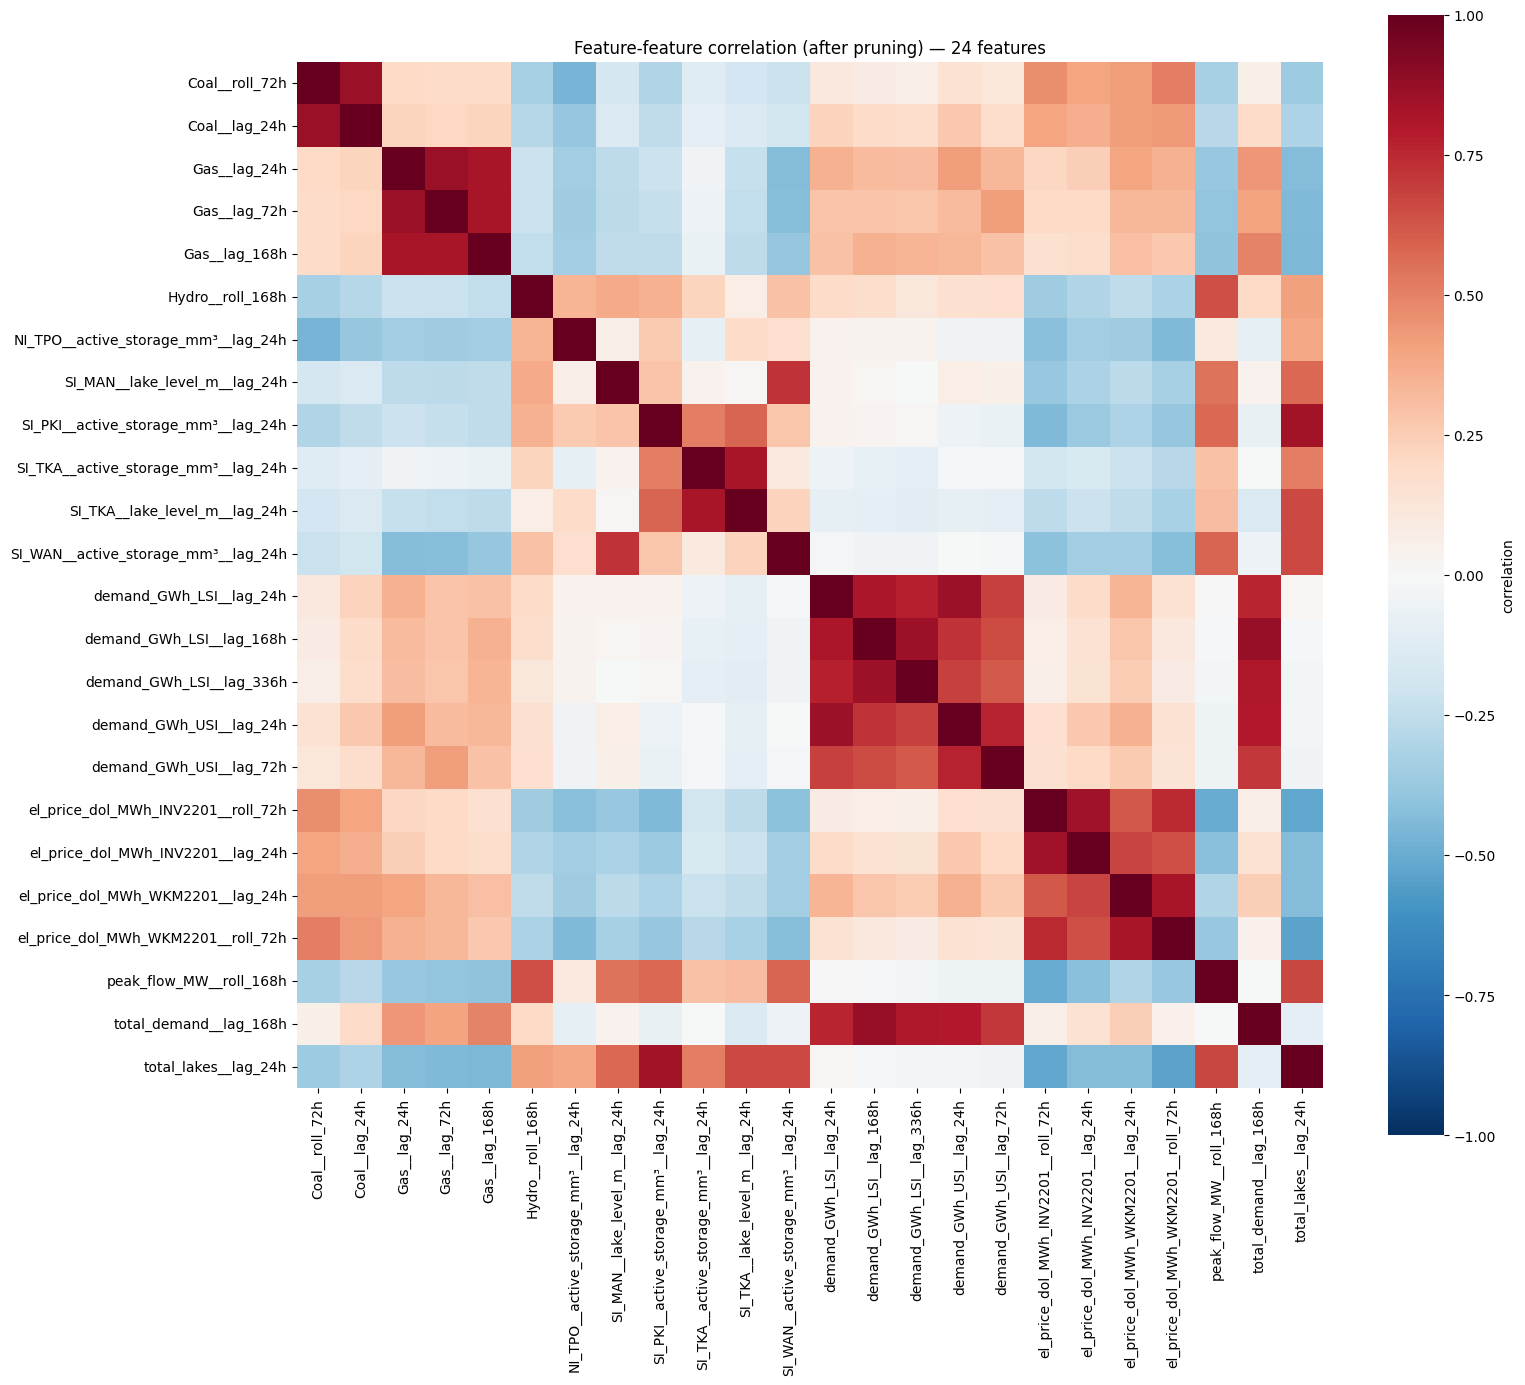

In [ ]:
# --- Step 4: Decide which features to drop ---
# For each high-correlation pair, drop the one with weaker target correlation

# Build a lookup: lagged-feature-name -> its target correlation
target_corr_lookup = {}
for feat, lag_records in feature_selection_dict.items():
    for record in lag_records:
        lag_name = record['lag']
        kind, n  = lag_map[lag_name]
        col_name = f'{feat}__lag_{n}h' if kind == 'shift' else f'{feat}__roll_{n}h'
        target_corr_lookup[col_name] = abs(record['lag_corr'])

to_drop = set()

for _, row in pairs.iterrows():
    a, b = row['feat_a'], row['feat_b']

    # If one is already dropped, skip
    if a in to_drop or b in to_drop:
        continue

    # Keep the one with stronger target correlation, drop the other
    if target_corr_lookup[a] >= target_corr_lookup[b]:
        to_drop.add(b)
    else:
        to_drop.add(a)

print(f'Features to drop: {len(to_drop)}')
print(f'Features to keep: {X_features.shape[1] - len(to_drop)}')

X_final = X_features.drop(columns=list(to_drop))
print(f'Final feature matrix: {X_final.shape}')

# Visualize final choice
plt.figure(figsize=(16, 14))
sns.heatmap(X_final.dropna().corr(),
            cmap='RdBu_r',
            center=0,
            vmin=-1,
            vmax=1,
            square=True,
            cbar_kws={'label': 'correlation'})
plt.title(f'Feature-feature correlation (after pruning) — {X_final.shape[1]} features')
plt.tight_layout()
plt.show()

# Notes from Claude

## What I'd verify before moving on

**One critical thing to lock in your memory** (and maybe add as a comment at the top of the notebook): your target is now `log1p(price)`, not raw price. Three downstream implications:

- XGBoost will train on log-prices and predict log-prices
- All your training metrics (MAE, RMSE) will be in log-space — `MAE = 0.3` doesn't mean "off by $0.30," it means roughly 30% relative error
- When you evaluate or deploy, you'll need `np.expm1(y_pred)` to get back to dollars before reporting numbers to the team

This is the easiest thing to forget and the source of the most "wait, why are the numbers tiny?" confusion later. Worth a sticky note.

## Two small things worth checking

**1. The negative-value features.** `christchurch_temp_c`, `hamilton_temp_c`, `dunedin_temp_c`, `avg_flow_MW`, `peak_flow_MW` were all skipped by the log transform automatically (because `log1p` needs values ≥ -1). Quick check: what does `dist_summary` show for their skewness? If any of them came back with `|skew| > 1` despite being skipped, they're still heavy-tailed and XGBoost would benefit from a transformation that handles negatives. The fix in that case is `PowerTransformer(method='yeo-johnson')` applied to just those columns. Not critical, but worth a glance.

**2. Cyclical time features.** I notice you don't have `hour_sin/cos` or `doy_sin/cos` as features. For XGBoost these are "helpful, not required" per our table — XGBoost can sometimes infer time patterns from raw features like demand (which itself follows daily cycles). If the model performs well without them, great. If you see it struggling at certain times of day, adding them is a cheap fix to try. Low priority for v1.

## What's not missing — confirming the pipeline is correct

The choices you described are all right:
- Multicollinearity at `0.9` for XGBoost ✓ (vs `0.7` for linear, `0.95` for LSTM)
- No scaling needed ✓ (XGBoost is scale-invariant)
- Aggregate features added before the correlation analysis ✓ (so they get evaluated with everything else)
- Log transform before correlation analysis ✓ (correlations reflect the actual feature shapes)
- The four negative features bypass log automatically ✓

The aggregate features (`total_demand`, `total_lakes`, `total_wind`, `total_solar`) will fight with their component columns in the multicollinearity step — that's expected and correct. Whichever has stronger target correlation survives. After running, it might be interesting to check `to_drop` and see whether the totals or the components survived. Tells you something about whether geographic granularity matters or whether the aggregate is enough.

## What's next

You've got `X_final` ready. The next moves are:
1. Chronological train/val/test split
2. Train an XGBoost baseline with sensible defaults
3. Compare against a naive baseline (last-value, same-hour-yesterday)
4. Then tune

Want to start on the train/val/test split next, or are you stopping here for the session?